## Sajid Mannan -- M3RG Lab -- Indian Institute of Technology, Delhi
## Date : 14April2026
## Glass Dissolution Prediction ##


## Importing Libraries

## Xg BOOSt

In [1]:
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
import sys
agrs = sys.argv
from functools import partial
import pandas as pd
import numpy as np
import MLPipeline as MLP
import os
import xgboost
import matplotlib
import shap
# from new_plot import *
# set_things()

In [83]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
def get_score(train_actual=0, train_predicted=0, test_actual=0, test_predicted=0):
    train_r2 = r2_score(train_actual, train_predicted)
    train_mae = mean_absolute_error(train_actual, train_predicted)
    train_mse = mean_squared_error(train_actual, train_predicted)

    test_r2 = r2_score(test_actual, test_predicted)
    test_mae = mean_absolute_error(test_actual, test_predicted)
    test_mse = mean_squared_error(test_actual, test_predicted)

    print(f'Training has R^2={train_r2.round(5)},mse={train_mse.round(5)} and mae={train_mae.round(5)}')
    print(f'Testing has R^2={test_r2.round(5)}, mse={test_mse.round(5)} and mae={test_mae.round(5)}')

    return {
        "Train_R2": round(train_r2, 3),
        "Train mse": round(train_mse, 3),
        "Train mae": round(train_mae, 3),
        "Test_R2": round(test_r2, 3),
        "Test mse": round(test_mse, 3),
        "Test mae": round(test_mae, 3)}

In [87]:
X_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_train_split_X.csv')
y_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_train_split_y.csv')
X_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_test_split_X.csv')
y_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_test_split_y.csv')

In [89]:
# X_train = X_train.iloc[:, :-10]
# X_test = X_test.iloc[:, :-10]
X_train

,O_per,NF_per,NM_per,valency_NF,valency_NM,automic_mass,automic_vol,A_number,automic_radius,vdwall_radius,...,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10
0,0.604258,0.263289,0.132453,303.856582,54.496952,6367.196059,2592.569508,3109.021782,655.302606,584.618557,...,9.886235,7.091496,11.033625,4.003721,4.119290,10.462847,7.934297,13.472701,7.244522,10.469156
1,0.778575,0.221425,0.000000,231.947999,0.000000,10694.794510,2935.879724,4915.062616,661.541056,578.206435,...,25.232798,13.547860,20.322374,10.504789,7.235515,-0.642869,0.724299,6.703285,14.743387,13.029710
2,0.680481,0.251867,0.067652,288.237442,24.722650,6607.828004,2492.356807,3270.192188,608.381054,541.555465,...,2.536642,-10.525118,13.190824,22.656776,17.525904,8.987157,6.080177,-3.493712,4.978676,12.194653
3,0.689389,0.214713,0.095898,223.317840,43.223119,6560.149082,2437.806720,3232.728171,576.806561,506.716521,...,14.707810,16.425592,16.566751,9.725747,10.351345,10.018402,-0.338060,7.217171,9.325678,1.958347
4,0.604377,0.273450,0.122172,323.059845,45.288333,6604.198935,2523.507004,3213.877903,638.158038,575.474416,...,21.245863,6.333387,11.956010,24.010519,15.122143,15.624169,7.067569,4.252579,21.373037,2.583429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
419,0.677498,0.266706,0.055796,310.134637,21.184254,6516.239178,2463.366574,3231.271936,605.634018,539.512238,...,14.707810,16.425592,16.566751,9.725747,10.351345,10.018402,-0.338060,7.217171,9.325678,1.958347
420,0.607871,0.244406,0.147723,279.521217,56.497294,6255.325773,2497.868188,3060.020852,620.186986,551.894312,...,9.886235,7.091496,11.033625,4.003721,4.119290,10.462847,7.934297,13.472701,7.244522,10.469156
421,0.617490,0.287396,0.095114,339.660000,36.760000,6431.590048,2572.231523,3174.240000,644.766500,582.372900,...,11.177767,-5.496496,23.767889,13.830687,-18.680714,8.916791,26.604070,-1.671965,-4.014891,-0.230322
422,0.681130,0.212140,0.106730,240.985497,47.606134,6910.567050,2629.354044,3409.151016,629.082843,555.129954,...,10.893426,6.653773,12.459437,12.606045,16.046923,16.697403,17.818232,6.114308,5.683449,6.101972


In [90]:
import json
file2 = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_NN_dissolution_descriptor/xgb_glass_dissolution_0/00_Pipeline_xgb_glass_dissolution_Node_Data Normalization_means_and_stds.json"
ms_file = json.load(open(file2, "rb"))
import pickle
file_name = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_NN_dissolution_descriptor/xgb_glass_dissolution_0/01_Pipeline_xgb_glass_dissolution_Node_Optuna XGBoost_Trial_142_8_model.pkl"
xgb_model_loaded = pickle.load(open(file_name, "rb"))


# UMAP - XGB

In [404]:
# #without comp NLPfeature
X_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_train_split_X.csv').iloc[:, :-10]
y_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_train_split_y.csv')
X_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_test_split_X.csv').iloc[:, :-10]
y_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_test_split_y.csv')
import json
file2 = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_dissolution_XGB_composition/xgb_dissolution_composition_NO_NLP_0/00_Pipeline_xgb_dissolution_composition_NO_NLP_Node_Data Normalization_means_and_stds.json"
ms_file = json.load(open(file2, "rb"))
import pickle
file_name = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_dissolution_XGB_composition/xgb_dissolution_composition_NO_NLP_0/01_Pipeline_xgb_dissolution_composition_NO_NLP_Node_Optuna XGBoost_Trial_148_6_model.pkl"
xgb_model_loaded = pickle.load(open(file_name, "rb"))

In [1063]:
# #des_NLP
X_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited/maxpooled_processed_output_edited/01_Pipeline_umap_dissolution_maxpooled_Node_train_test_split_train_split_X.csv')
y_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited/maxpooled_processed_output_edited/01_Pipeline_umap_dissolution_maxpooled_Node_train_test_split_train_split_y.csv')
X_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited/maxpooled_processed_output_edited/01_Pipeline_umap_dissolution_maxpooled_Node_train_test_split_test_split_X.csv')
y_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited/maxpooled_processed_output_edited/01_Pipeline_umap_dissolution_maxpooled_Node_train_test_split_test_split_y.csv')
import json
file2 = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_dissolution_XGB_descriptor/xgb_dissolution_descriptor_0/00_Pipeline_xgb_dissolution_descriptor_Node_Data Normalization_means_and_stds.json"
ms_file = json.load(open(file2, "rb"))
import pickle
file_name = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_dissolution_XGB_descriptor/xgb_dissolution_descriptor_0/01_Pipeline_xgb_dissolution_descriptor_Node_Optuna XGBoost_Trial_43_4_model.pkl"
xgb_model_loaded = pickle.load(open(file_name, "rb"))


In [1072]:
## comp_NLP
X_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_train_split_X.csv')
y_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_train_split_y.csv')
X_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_test_split_X.csv')
y_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_test_split_y.csv')

import json
file2 = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_dissolution_XGB_composition/xgb_dissolution_composition_0/00_Pipeline_xgb_dissolution_composition_Node_Data Normalization_means_and_stds.json"
ms_file = json.load(open(file2, "rb"))
import pickle
file_name = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_dissolution_XGB_composition/xgb_dissolution_composition_0/01_Pipeline_xgb_dissolution_composition_Node_Optuna XGBoost_Trial_44_3_model.pkl"
xgb_model_loaded = pickle.load(open(file_name, "rb"))

In [1073]:
# file_name = "/home/civil/phd/cez218288/scratch/Sidarth_dissolution/2b_xgb_results_Si/01_Pipeline_Si_Node_Optuna XGBoost_Trial_163_3_model.pkl"
# /home/civil/phd/cez218288/scratch/Sidarth_dissolution/2a_xgb_results_Si_BERT_16_ZERO/01_Pipeline_Si_BERT_16_Node_Optuna XGBoost_Trial_181_3_model.pkl
#/home/civil/phd/cez218288/scratch/Sidarth_dissolution/2b_xgb_results_des_Si/01_Pipeline_des_Si_Node_Optuna XGBoost_Trial_441_1_model.pkl
#/home/civil/phd/cez218288/scratch/Sidarth_dissolution/2a_xgb_results_Si_BERT_des_16_ZERO/01_Pipeline_Si_des_BERT_16_Node_Optuna XGBoost_Trial_213_3_model.pkl
#/home/civil/phd/cez218288/scratch/Sidarth_dissolution/2a_xgb_results_Si_Benchmarking_Final_dss/01_Pipeline_Si_Benchmarking_des_Node_Optuna XGBoost_Trial_109_3_model.pkl

# PCA-XGB

In [1379]:
# #des_NLP
X_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/pca_maxpooled_processed_output_edited/01_Pipeline_pca_dissolution_maxpooled_Node_train_test_split_train_split_X.csv')
y_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/pca_maxpooled_processed_output_edited/01_Pipeline_pca_dissolution_maxpooled_Node_train_test_split_train_split_y.csv')
X_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/pca_maxpooled_processed_output_edited/01_Pipeline_pca_dissolution_maxpooled_Node_train_test_split_test_split_X.csv')
y_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/pca_maxpooled_processed_output_edited/01_Pipeline_pca_dissolution_maxpooled_Node_train_test_split_test_split_y.csv')
import json
file2 = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_dissolution_XGB_descriptor_pca/xgb_dissolution_descriptor_0/00_Pipeline_xgb_dissolution_descriptor_Node_Data Normalization_means_and_stds.json"
ms_file = json.load(open(file2, "rb"))
import pickle
file_name = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_dissolution_XGB_descriptor_pca/xgb_dissolution_descriptor_0/01_Pipeline_xgb_dissolution_descriptor_Node_Optuna XGBoost_Trial_66_3_model.pkl"
xgb_model_loaded = pickle.load(open(file_name, "rb"))


In [1473]:
## comp_NLP
X_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/pca_maxpooled_processed_output_edited_composition/pca_maxpooled_processed_output_edited_composition/01_Pipeline_pca_dissolution_maxpooled_comp_Node_train_test_split_train_split_X.csv')
y_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/pca_maxpooled_processed_output_edited_composition/pca_maxpooled_processed_output_edited_composition/01_Pipeline_pca_dissolution_maxpooled_comp_Node_train_test_split_train_split_y.csv')
X_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/pca_maxpooled_processed_output_edited_composition/pca_maxpooled_processed_output_edited_composition/01_Pipeline_pca_dissolution_maxpooled_comp_Node_train_test_split_test_split_X.csv')
y_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/pca_maxpooled_processed_output_edited_composition/pca_maxpooled_processed_output_edited_composition/01_Pipeline_pca_dissolution_maxpooled_comp_Node_train_test_split_test_split_y.csv')

import json
file2 = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_dissolution_XGB_composition_pca/xgb_dissolution_composition_1/00_Pipeline_xgb_dissolution_composition_Node_Data Normalization_means_and_stds.json"
ms_file = json.load(open(file2, "rb"))
import pickle
file_name = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_dissolution_XGB_composition_pca/xgb_dissolution_composition_1/01_Pipeline_xgb_dissolution_composition_Node_Optuna XGBoost_Trial_68_5_model.pkl"
xgb_model_loaded = pickle.load(open(file_name, "rb"))

In [1474]:
mean=ms_file["means"]

In [1475]:
std=ms_file["stds"]

In [1476]:
(X_train.shape),len(y_train.shape)

((424, 65), 2)

In [1477]:
len(mean)

66

In [1478]:
P = MLP.Pipe(name="Combined", output="2a_xgb_results_Si_BERT_ullo_ZERO")
P.add(MLP.data_cleaning.normalize_data(mean=ms_file["means"], std=ms_file["stds"]))  ##(x-mean)/(std)

X_train_N, y_train_N = P((X_train, y_train))
X_test_N, y_test_N = P((X_test, y_test))


Pipeline Combined is running

Node 0 running.
Node name:  Data Normalization

Pipeline Combined is running

Node 0 running.
Node name:  Data Normalization


In [1479]:
train_r2 = xgb_model_loaded.score(X_train_N,y_train_N)
test_r2 = xgb_model_loaded.score(X_test_N,y_test_N)
print(train_r2,test_r2)

0.9377080657445447 0.8691003152518315


In [1480]:
mean=ms_file["means"]
std=ms_file["stds"]
y_test_pred=xgb_model_loaded.predict(X_test_N)
Y = mean[-1] + y_test_pred*std[-1]
mean=ms_file["means"]
std=ms_file["stds"]
y_train_pred=xgb_model_loaded.predict(X_train_N)
Y_train = mean[-1] + y_train_pred*std[-1]
y1 = y_test.to_numpy().reshape(-1,1)  ## y1 is y_test
y2 = Y.reshape(-1,1) ## y2 is y_test_pred
y1_train = y_train.to_numpy() ## actual y_train
y2_train = Y_train.reshape(-1,1)   ## predicted y_train
print(y2.shape, y2.shape, y1_train.shape,y2_train.shape)
X_data_all= pd.concat([X_train_N,X_test_N], ignore_index = True)
X_data_all_a = mean[:-1] + X_data_all*std[:-1]

(107, 1) (107, 1) (424, 1) (424, 1)


In [1425]:
mean=ms_file["means"]
std=ms_file["stds"]
y_test_pred=xgb_model_loaded.predict(X_test_N)
Y = mean[-1] + y_test_pred*std[-1]

In [1426]:
mean=ms_file["means"]
std=ms_file["stds"]
y_train_pred=xgb_model_loaded.predict(X_train_N)
Y_train = mean[-1] + y_train_pred*std[-1]

In [1390]:
y1 = y_test.to_numpy().reshape(-1,1)  ## y1 is y_test
y2 = Y.reshape(-1,1) ## y2 is y_test_pred
y1_train = y_train.to_numpy() ## actual y_train
y2_train = Y_train.reshape(-1,1)   ## predicted y_train
print(y2.shape, y2.shape, y1_train.shape,y2_train.shape)

(107, 1) (107, 1) (424, 1) (424, 1)


In [1391]:
X_data_all= pd.concat([X_train_N,X_test_N], ignore_index = True)

In [1392]:
X_data_all_a = mean[:-1] + X_data_all*std[:-1]

Training has R^2=0.93088,mse=0.99645 and mae=0.76332
Testing has R^2=0.88314, mse=1.49305 and mae=0.86527


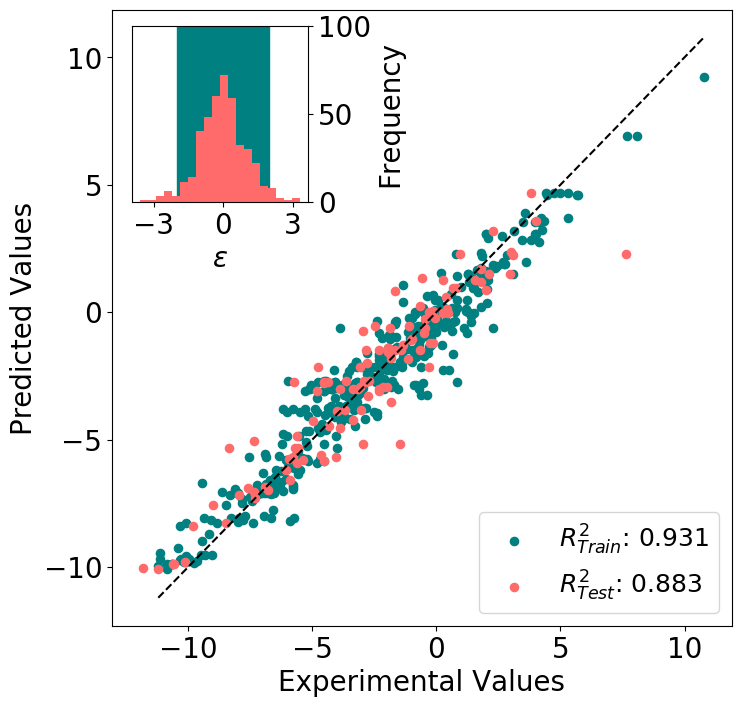

In [1393]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.rcParams['font.family'] = 'Arial'
# plt.figure(figsize=(8,8))
fig,ax1 = plt.subplots(figsize =(8,8))
ax1.scatter(y1_train,y2_train, s =35,color =['#008080'])
ax1.scatter(y1,y2, s =35,color =["#FF6B6B"])
# ax1.scatter(y1_train,y2_train, s =20,color =['#007FFF'])
# ax1.scatter(y1,y2, s =20,color =["#FF004F"])
score=get_score(train_actual=y1_train,train_predicted=y2_train,
              test_actual=y1,test_predicted=y2)
ax1.legend(['$R^2_{{Train}}$' + f": {score['Train_R2']}",'$R^2_{{Test}}$' + f": {score['Test_R2']}"], loc = 'lower right',fontsize = 18)

# # Add axis labels
ax1.set_ylabel('Predicted Values',fontsize = 20)
ax1.set_xlabel('Experimental Values', fontsize = 20)
ax1.yaxis.set_tick_params(labelsize =20)
ax1.xaxis.set_tick_params(labelsize =20)
min_val = min(min(y1_train), min(y2_train))
max_val = max(max(y1_train), max(y2_train))
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--') 
# ax1.set_ylim(min(y2_train),max(y2_train)+2.1)
# ax1.set_xlim(min(y1_train),max(y1_train))
left, bottom, width, height = [0.15, 0.64, 0.22, 0.22]
ax2 = fig.add_axes([left, bottom, width, height])
std=np.std(y2_train-y1_train)
mean=np.mean(y2_train-y1_train)
xx=mean-2*std # 0.21-(2*std)
yy = 0
mean = np.mean(y2_train-y1_train)
rec = patches.Rectangle((xx,yy),4*std,600, color ='#008080')#,edgecolor='#3C3D37')
ax2.add_patch(rec)
y,x,__ = plt.hist(y2_train-y1_train, bins =20,color=['#FF6B6B'])
ax2.xaxis.set_major_locator(plt.MaxNLocator(3))
xlabel_ax2 = ax2.get_xticklabels()
ax2.yaxis.tick_right()
ax2.yaxis.set_tick_params(labelsize =20)
ax2.xaxis.set_tick_params(labelsize =20)
ax2.yaxis.set_label_position("right")
ax2.set_ylim(0,100)
# ax2.set_xlim(-3,3)
ax2.set_ylabel('Frequency',fontsize=20)
ax2.set_xlabel(r'$\epsilon$',fontsize=20)
# 
# plt.savefig('/home/civil/phd/cez218288/scratch/Sidarth_dissolution/plots/ALTG_Si_Xg.png',format='png', dpi=300)["#008080","#FF6B6B"
plt.show()

Training has R^2=0.93088,mse=0.99645 and mae=0.76332
Testing has R^2=0.88314, mse=1.49305 and mae=0.86527


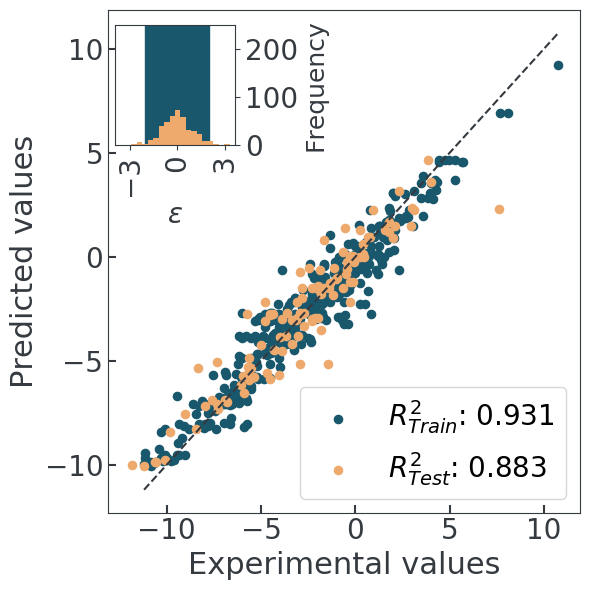

In [1394]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Set global font to Arial
plt.rcParams['font.family'] = 'Arial'

font_color = '#343a40'

fig, ax1 = plt.subplots(figsize=(6, 6))

# Main scatter plots
ax1.scatter(y1_train, y2_train, s=35, color=['#19576C'])
ax1.scatter(y1, y2, s=35, color=["#EEA96D"])

# Scores and legend
score = get_score(train_actual=y1_train, train_predicted=y2_train,
                  test_actual=y1, test_predicted=y2)
ax1.legend(
    [f'$R^2_{{Train}}$: {score["Train_R2"]:.3f}', f'$R^2_{{Test}}$: {score["Test_R2"]:.3f}'],
    loc='lower right',
    fontsize=20,
    frameon=True
)

# Axis labels
ax1.set_xlabel('Experimental values', fontsize=22, color=font_color)
ax1.set_ylabel('Predicted values', fontsize=22, color=font_color)

# Tick parameters and spine color match
ax1.tick_params(axis="both", direction="in", length=6, width=1.5, labelsize=20, colors=font_color)
for spine in ax1.spines.values():
    spine.set_color(font_color)

# Diagonal line
min_val = min(min(y1_train), min(y2_train))
max_val = max(max(y1_train), max(y2_train))
ax1.plot([min_val, max_val], [min_val, max_val], color=font_color, linestyle='--')
ax1.set_xticks(np.arange(-10, 11, 5))  # from -10 to 10, step 5
ax1.set_yticks(np.arange(-10, 11, 5))
# Inset histogram
left, bottom, width, height = [0.2, 0.75, 0.2, 0.2]
ax2 = fig.add_axes([left, bottom, width, height])

# Histogram shaded region
std = np.std(y2_train - y1_train)
mean = np.mean(y2_train - y1_train)
xx = mean - 2 * std
yy = 0
rec = patches.Rectangle((xx, yy), 4 * std, 600, color='#19576C')
ax2.add_patch(rec)

# Histogram itself
y, x, __ = ax2.hist(y2_train - y1_train, bins=20, color='#EEA96D')

# Tick styling for inset
ax2.xaxis.set_major_locator(plt.MaxNLocator(3))
ax2.yaxis.tick_right()
ax2.yaxis.set_tick_params(labelsize=20, colors=font_color)
ax2.xaxis.set_tick_params(labelsize=20, colors=font_color)
ax2.yaxis.set_label_position("right")

# Inset labels
ax2.set_ylabel('Frequency', fontsize=18, color=font_color)
ax2.set_xlabel(r'$\epsilon$', fontsize=20, color=font_color)
ax2.set_ylim(0, 250)
ax2.set_yticks([0, 100, 200])
ax2.tick_params(axis='x', labelrotation=90)

# Match spine color in inset
for spine in ax2.spines.values():
    spine.set_color(font_color)

plt.tight_layout()
plt.show()


In [539]:
hex = ['#156082', '#519E8A', '#476A6F', '#7EB09B', '#C5C9A4', '#00ADB5', '#B3C5D7']


## Neural Network

In [4]:
import torch
from sklearn.metrics import r2_score
import pandas as pd

In [270]:
# ## comp_NLP
# X_train = pd.read_csv('/home/civil/phd/cez218288/scratch/dissolution/1b_processed_data_umap_NLP/01_Pipeline_Si_Bench_des_Node_train_test_split_train_split_X.csv')
# y_train = pd.read_csv('/home/civil/phd/cez218288/scratch/dissolution/1b_processed_data_umap_NLP/01_Pipeline_Si_Bench_des_Node_train_test_split_train_split_y.csv')
# X_test = pd.read_csv('/home/civil/phd/cez218288/scratch/dissolution/1b_processed_data_umap_NLP/01_Pipeline_Si_Bench_des_Node_train_test_split_test_split_X.csv')
# y_test = pd.read_csv('/home/civil/phd/cez218288/scratch/dissolution/1b_processed_data_umap_NLP/01_Pipeline_Si_Bench_des_Node_train_test_split_test_split_y.csv')

# import json
# file2 = "/home/civil/phd/cez218288/scratch/dissolution/2a_nn_results_NLP/00_Pipeline_with_nlp_Node_Data Normalization_means_and_stds.json"
# ms_file = json.load(open(file2, "rb"))
# import pickle
# file_name = "/home/civil/phd/cez218288/scratch/dissolution/2a_nn_results_NLP/01_Pipeline_with_nlp_Node_Optuna NN_Trial_175_2_model.pkl"
# nn_model_loaded = pickle.load(open(file_name, "rb"))

# UMAP - NN

In [5]:
#comp_NO_NLP
X_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_train_split_X.csv').iloc[:, :-10]
y_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_train_split_y.csv')
X_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_test_split_X.csv').iloc[:, :-10]
y_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_test_split_y.csv')

import json
file2 = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_NN_dissolution_composition/NN_dissolution_composition_NO_NLP_0/00_Pipeline_NN_dissolution_composition_NO_NLP_Node_Data Normalization_means_and_stds.json"
ms_file = json.load(open(file2, "rb"))
import pickle
file_name = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_NN_dissolution_composition/NN_dissolution_composition_NO_NLP_0/01_Pipeline_NN_dissolution_composition_NO_NLP_Node_Optuna NN_Trial_136_8_model.pkl"
nn_model_loaded = pickle.load(open(file_name, "rb"))

In [1706]:
#des_NLP
X_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited/maxpooled_processed_output_edited/01_Pipeline_umap_dissolution_maxpooled_Node_train_test_split_train_split_X.csv')
y_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited/maxpooled_processed_output_edited/01_Pipeline_umap_dissolution_maxpooled_Node_train_test_split_train_split_y.csv')
X_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited/maxpooled_processed_output_edited/01_Pipeline_umap_dissolution_maxpooled_Node_train_test_split_test_split_X.csv')
y_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited/maxpooled_processed_output_edited/01_Pipeline_umap_dissolution_maxpooled_Node_train_test_split_test_split_y.csv')

import json
file2 = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_NN_dissolution_descriptor/NN_dissolution_descriptor_0/00_Pipeline_NN_dissolution_descriptor_Node_Data Normalization_means_and_stds.json"
ms_file = json.load(open(file2, "rb"))
import pickle
file_name = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_NN_dissolution_descriptor/NN_dissolution_descriptor_0/01_Pipeline_NN_dissolution_descriptor_Node_Optuna NN_Trial_63_9_model.pkl"
nn_model_loaded = pickle.load(open(file_name, "rb"))


In [31]:
#comp_NLP
X_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_train_split_X.csv')
y_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_train_split_y.csv')
X_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_test_split_X.csv')
y_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_test_split_y.csv')

import json
file2 = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_NN_dissolution_composition/NN_dissolution_composition_0/00_Pipeline_NN_dissolution_composition_Node_Data Normalization_means_and_stds.json"
ms_file = json.load(open(file2, "rb"))
import pickle
file_name = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_NN_dissolution_composition/NN_dissolution_composition_0/01_Pipeline_NN_dissolution_composition_Node_Optuna NN_Trial_101_8_model.pkl"
nn_model_loaded = pickle.load(open(file_name, "rb"))

# PCA-NN

In [1764]:
#comp_NLP
X_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/pca_maxpooled_processed_output_edited_composition/pca_maxpooled_processed_output_edited_composition/01_Pipeline_pca_dissolution_maxpooled_comp_Node_train_test_split_train_split_X.csv')
y_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/pca_maxpooled_processed_output_edited_composition/pca_maxpooled_processed_output_edited_composition/01_Pipeline_pca_dissolution_maxpooled_comp_Node_train_test_split_train_split_y.csv')
X_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/pca_maxpooled_processed_output_edited_composition/pca_maxpooled_processed_output_edited_composition/01_Pipeline_pca_dissolution_maxpooled_comp_Node_train_test_split_test_split_X.csv')
y_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/pca_maxpooled_processed_output_edited_composition/pca_maxpooled_processed_output_edited_composition/01_Pipeline_pca_dissolution_maxpooled_comp_Node_train_test_split_test_split_y.csv')

import json
file2 = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_NN_dissolution_composition_pca/NN_dissolution_composition_1/00_Pipeline_NN_dissolution_composition_Node_Data Normalization_means_and_stds.json"
ms_file = json.load(open(file2, "rb"))
import pickle
file_name = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_NN_dissolution_composition_pca/NN_dissolution_composition_1/01_Pipeline_NN_dissolution_composition_Node_Optuna NN_Trial_130_1_model.pkl"
nn_model_loaded = pickle.load(open(file_name, "rb"))

In [70]:
#des_NLP
X_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/pca_maxpooled_processed_output_edited/01_Pipeline_pca_dissolution_maxpooled_Node_train_test_split_train_split_X.csv')
y_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/pca_maxpooled_processed_output_edited/01_Pipeline_pca_dissolution_maxpooled_Node_train_test_split_train_split_y.csv')
X_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/pca_maxpooled_processed_output_edited/01_Pipeline_pca_dissolution_maxpooled_Node_train_test_split_test_split_X.csv')
y_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/pca_maxpooled_processed_output_edited/01_Pipeline_pca_dissolution_maxpooled_Node_train_test_split_test_split_y.csv')

import json
file2 = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_NN_dissolution_descriptor_pca/NN_dissolution_descriptor_0/00_Pipeline_NN_dissolution_descriptor_Node_Data Normalization_means_and_stds.json"
ms_file = json.load(open(file2, "rb"))
import pickle
file_name = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_NN_dissolution_descriptor_pca/NN_dissolution_descriptor_0/01_Pipeline_NN_dissolution_descriptor_Node_Optuna NN_Trial_125_4_model.pkl"
nn_model_loaded = pickle.load(open(file_name, "rb"))

In [71]:
X_train

,O_per,NF_per,NM_per,valency_NF,valency_NM,automic_mass,automic_vol,A_number,automic_radius,vdwall_radius,...,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10
0,0.572133,0.240218,0.187649,274.600000,67.760000,6891.129745,2664.255717,3323.780000,654.506400,599.785500,...,16.113768,9.649345,9.482499,13.743604,14.219956,12.472912,9.302275,8.984632,9.079669,9.743258
1,0.677498,0.266706,0.055796,310.134637,21.184254,6516.239178,2463.366574,3231.271936,605.634018,539.512238,...,10.664939,11.604802,18.509612,8.923161,8.393658,8.996172,8.541837,10.503209,8.501023,7.969846
2,0.670656,0.277450,0.051894,331.775826,16.253695,6508.099235,2470.403709,3232.978658,613.252079,549.826117,...,10.837387,13.028576,17.552870,8.658179,8.647857,9.060886,8.150817,10.192808,7.915865,8.149227
3,0.617311,0.293439,0.089250,356.597340,31.366235,7025.087077,2658.214217,3417.385325,677.474013,615.650927,...,24.138529,17.273010,9.974881,10.299455,9.645569,11.778238,10.304784,10.571575,7.097519,9.963351
4,0.620603,0.275342,0.104055,324.636238,39.372142,6924.329402,2539.043898,3361.007917,640.580867,577.635997,...,24.138529,17.273010,9.974881,10.299455,9.645569,11.778238,10.304784,10.571575,7.097519,9.963351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
419,0.593255,0.210972,0.195773,239.113395,80.559052,6505.357121,2453.594040,3226.036357,564.728493,516.637668,...,24.484655,10.563364,10.266364,10.478342,7.851832,18.553610,9.044608,8.926831,7.165612,8.205591
420,0.626897,0.287226,0.085877,342.680000,35.000000,6984.414686,2720.171894,3429.680000,678.643000,610.438400,...,23.702267,9.277073,9.624686,10.626714,19.590229,10.303382,7.756071,9.823868,9.043880,7.997572
421,0.675422,0.267430,0.057148,313.100719,19.406686,6526.611308,2477.408101,3237.207172,610.387328,544.993119,...,10.837387,13.028576,17.552870,8.658179,8.647857,9.060886,8.150817,10.192808,7.915865,8.149227
422,0.671330,0.268029,0.060641,317.607867,19.164726,6578.013804,2488.728264,3262.002262,614.984234,550.858970,...,10.837387,13.028576,17.552870,8.658179,8.647857,9.060886,8.150817,10.192808,7.915865,8.149227


In [72]:
mean=ms_file["means"]

In [73]:
len(mean)

26

In [74]:
P = MLP.Pipe(name="Combined", output="2a_xgb_results_Si_BERT_16_ZERO")
P.add(MLP.data_cleaning.normalize_data(mean=ms_file["means"], std=ms_file["stds"]))  ##(x-mean)/(std)

X_train_N, y_train_N = P((X_train, y_train))
X_test_N, y_test_N = P((X_test, y_test))


Pipeline Combined is running

Node 0 running.
Node name:  Data Normalization

Pipeline Combined is running

Node 0 running.
Node name:  Data Normalization


In [75]:
y_train_pred=nn_model_loaded(torch.tensor(X_train_N.values).float()).detach().numpy()
y_test_pred=nn_model_loaded(torch.tensor(X_test_N.values).float()).detach().numpy()


In [76]:
print("R2_train: %s, R2_test: %s"%(r2_score(y_train_N,y_train_pred),r2_score(y_test_N,y_test_pred)))

R2_train: 0.9595255294879079, R2_test: 0.8948380036587735


In [77]:
mean=ms_file["means"]
std=ms_file["stds"]
y_test_pred=nn_model_loaded(torch.tensor(X_test_N.values).float()).detach().numpy()
Y = mean[-1] + y_test_pred*std[-1]

In [78]:
mean=ms_file["means"]
std=ms_file["stds"]
y_train_pred=nn_model_loaded(torch.tensor(X_train_N.values).float()).detach().numpy()
Y_train = mean[-1] + y_train_pred*std[-1]

In [84]:
y1 = y_test.to_numpy()
y2 = Y
y1_train = y_train.to_numpy()
y2_train = Y_train
print(y2.shape, Y.shape, y1_train.shape,y2_train.shape)

(107, 1) (107, 1) (424, 1) (424, 1)


In [85]:
X_data_all= pd.concat([X_train_N,X_test_N], ignore_index = True)

In [86]:
X_data_all_a = mean[:-1] + X_data_all*std[:-1]

Training has R^2=0.95953,mse=0.58353 and mae=0.53648
Testing has R^2=0.89484, mse=1.34365 and mae=0.8057


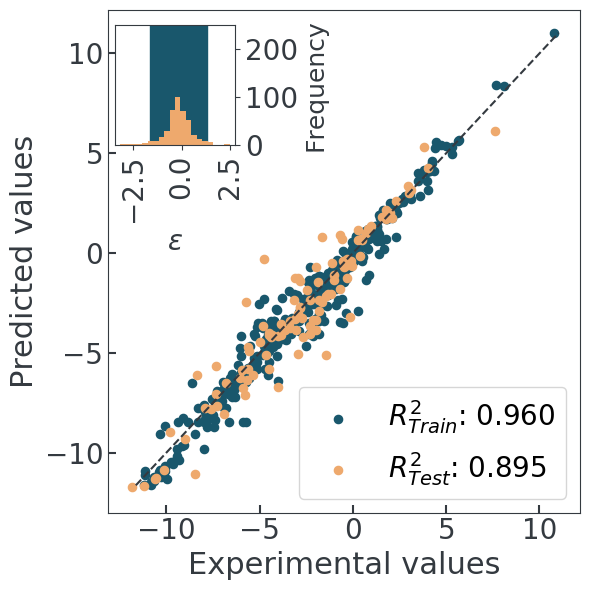

In [87]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Set global font to Arial
plt.rcParams['font.family'] = 'Arial'

font_color = '#343a40'

fig, ax1 = plt.subplots(figsize=(6, 6))

# Main scatter plots
ax1.scatter(y1_train, y2_train, s=35, color=['#19576C'])
ax1.scatter(y1, y2, s=35, color=["#EEA96D"])

# Scores and legend
score = get_score(train_actual=y1_train, train_predicted=y2_train,
                  test_actual=y1, test_predicted=y2)
ax1.legend(
    [f'$R^2_{{Train}}$: {score["Train_R2"]:.3f}', f'$R^2_{{Test}}$: {score["Test_R2"]:.3f}'],
    loc='lower right',
    fontsize=20,
    frameon=True
)

# Axis labels
ax1.set_xlabel('Experimental values', fontsize=22, color=font_color)
ax1.set_ylabel('Predicted values', fontsize=22, color=font_color)

# Tick parameters and spine color match
ax1.tick_params(axis="both", direction="in", length=6, width=1.5, labelsize=20, colors=font_color)
for spine in ax1.spines.values():
    spine.set_color(font_color)

# Diagonal line
min_val = min(min(y1_train), min(y2_train))
max_val = max(max(y1_train), max(y2_train))
ax1.plot([min_val, max_val], [min_val, max_val], color=font_color, linestyle='--')
ax1.set_xticks(np.arange(-10, 11, 5))  # from -10 to 10, step 5
ax1.set_yticks(np.arange(-10, 11, 5))
# Inset histogram
left, bottom, width, height = [0.2, 0.75, 0.2, 0.2]
ax2 = fig.add_axes([left, bottom, width, height])

# Histogram shaded region
std = np.std(y2_train - y1_train)
mean = np.mean(y2_train - y1_train)
xx = mean - 2 * std
yy = 0
rec = patches.Rectangle((xx, yy), 4 * std, 600, color='#19576C')
ax2.add_patch(rec)

# Histogram itself
y, x, __ = ax2.hist(y2_train - y1_train, bins=20, color='#EEA96D')

# Tick styling for inset
ax2.xaxis.set_major_locator(plt.MaxNLocator(3))
ax2.yaxis.tick_right()
ax2.yaxis.set_tick_params(labelsize=20, colors=font_color)
ax2.xaxis.set_tick_params(labelsize=20, colors=font_color)
ax2.yaxis.set_label_position("right")

# Inset labels
ax2.set_ylabel('Frequency', fontsize=18, color=font_color)
ax2.set_xlabel(r'$\epsilon$', fontsize=20, color=font_color)
ax2.set_ylim(0, 250)
ax2.set_yticks([0, 100, 200])
ax2.tick_params(axis='x', labelrotation=90)

# Match spine color in inset
for spine in ax2.spines.values():
    spine.set_color(font_color)

plt.tight_layout()
plt.show()


## prediction on new dataset

In [26]:
new_data=pd.read_csv("/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/Diss_model_training/unseen_glass_descriptor_final_max_pca.csv")

In [27]:
X_train=pd.DataFrame(new_data.iloc[:,:-1])
y_train=pd.DataFrame(np.log(new_data.iloc[:,-1]))

In [28]:
X_train.shape, y_train.shape

((32, 25), (32, 1))

In [29]:
# ## NN Des Model
# import json
# file2 = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_NN_dissolution_descriptor/NN_dissolution_descriptor_0/00_Pipeline_NN_dissolution_descriptor_Node_Data Normalization_means_and_stds.json"
# ms_file = json.load(open(file2, "rb"))
# import pickle
# file_name = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_NN_dissolution_descriptor/NN_dissolution_descriptor_0/01_Pipeline_NN_dissolution_descriptor_Node_Optuna NN_Trial_63_9_model.pkl"
# nn_model_loaded = pickle.load(open(file_name, "rb"))


In [30]:
# ## XGB Des Model
# import json
# file2 = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_dissolution_XGB_descriptor/xgb_dissolution_descriptor_0/00_Pipeline_xgb_dissolution_descriptor_Node_Data Normalization_means_and_stds.json"
# ms_file = json.load(open(file2, "rb"))
# import pickle
# file_name = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_dissolution_XGB_descriptor/xgb_dissolution_descriptor_0/01_Pipeline_xgb_dissolution_descriptor_Node_Optuna XGBoost_Trial_43_4_model.pkl"
# xgb_model_loaded = pickle.load(open(file_name, "rb"))

In [31]:
## PCA NN Des Model
import json
file2 = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_NN_dissolution_descriptor_pca/NN_dissolution_descriptor_0/00_Pipeline_NN_dissolution_descriptor_Node_Data Normalization_means_and_stds.json"
ms_file = json.load(open(file2, "rb"))
import pickle
file_name = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_NN_dissolution_descriptor_pca/NN_dissolution_descriptor_0/01_Pipeline_NN_dissolution_descriptor_Node_Optuna NN_Trial_125_4_model.pkl"
nn_model_loaded = pickle.load(open(file_name, "rb"))

In [32]:
mean=ms_file["means"]

In [33]:
len(mean)

26

In [34]:
std=ms_file["stds"]

In [35]:
P = MLP.Pipe(name="Combined", output="2a_xgb_results_Si_BERT_ullo_ZERO")
P.add(MLP.data_cleaning.normalize_data(mean=ms_file["means"], std=ms_file["stds"]))  ##(x-mean)/(std)

X_train_N, y_train_N = P((X_train, y_train))
# X_test_N, y_test_N = P((X_test, y_test))


Pipeline Combined is running

Node 0 running.
Node name:  Data Normalization


In [36]:
## NN Model Predictions
y_train_pred=nn_model_loaded(torch.tensor(X_train_N.values).float()).detach().numpy()

print("R2_train: %s"%(r2_score(y_train_N,y_train_pred)))

R2_train: -1.2501355717795337


In [37]:
# ## XGB Model Predictions
# train_r2 = xgb_model_loaded.score(X_train_N,y_train_N)
# print(train_r2)

In [38]:
mean=ms_file["means"]
std=ms_file["stds"]
y_train_pred=nn_model_loaded(torch.tensor(X_train_N.values).float()).detach().numpy()
Y_train = mean[-1] + y_train_pred*std[-1]

In [40]:
# y1 = y_test.to_numpy()
# y2 = Y
y1_train = y_train.to_numpy()
y2_train = Y_train
print(y1_train.shape,y2_train.shape)

(32, 1) (32, 1)


In [41]:
def get_score(train_actual=0, train_predicted=0):
    train_r2 = r2_score(train_actual, train_predicted)
    train_mae = mean_absolute_error(train_actual, train_predicted)
    train_mse = mean_squared_error(train_actual, train_predicted)

    

    print(f'Training has R^2={train_r2.round(5)},mse={train_mse.round(5)} and mae={train_mae.round(5)}')
    # print(f'Testing has R^2={test_r2.round(5)}, mse={test_mse.round(5)} and mae={test_mae.round(5)}')

    return {
        "Train_R2": round(train_r2, 3),
        "Train mse": round(train_mse, 3),
        "Train mae": round(train_mae, 3),}

Training has R^2=-1.25014,mse=10.45624 and mae=3.02231


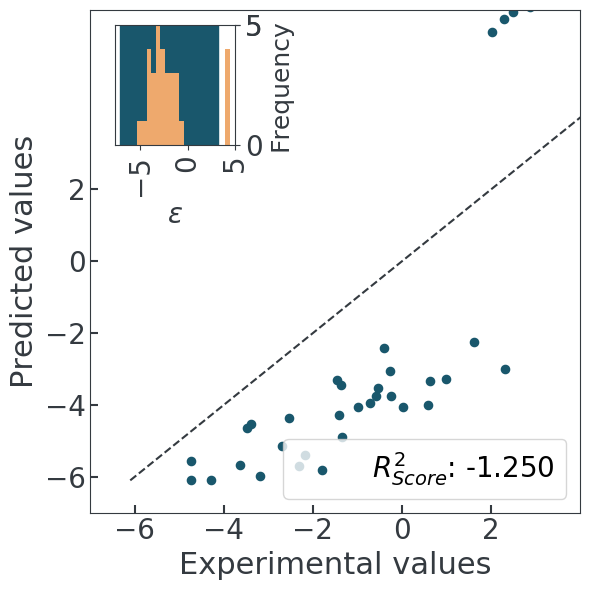

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Set global font to Arial
plt.rcParams['font.family'] = 'Arial'
font_color = '#343a40'

fig, ax1 = plt.subplots(figsize=(6, 6))

# Main scatter plot (train data only)
ax1.scatter(y1_train, y2_train, s=35, color=['#19576C'])

# Compute score using only the train data
score = get_score(train_actual=y1_train, train_predicted=y2_train)

# Show only the train score in the legend
ax1.legend(
    [f'$R^2_{{Score}}$: {score["Train_R2"]:.3f}'],
    loc='lower right',
    fontsize=20,
    frameon=True
)

# Axis labels
ax1.set_xlabel('Experimental values', fontsize=22, color=font_color)
ax1.set_ylabel('Predicted values', fontsize=22, color=font_color)

# Tick parameters and spine color match
ax1.tick_params(axis="both", direction="in", length=6, width=1.5, labelsize=20, colors=font_color)
for spine in ax1.spines.values():
    spine.set_color(font_color)

# Diagonal line based on train data
min_val = min(min(y1_train), min(y2_train))
max_val = max(max(y1_train), max(y2_train))
ax1.plot([min_val, max_val], [min_val, max_val], color=font_color, linestyle='--')

# ── Fixed axis range and ticks from -6 to +6 in steps of 2 ──────────────────
tick_values1 = np.arange(-6, 3, 2)   # [-6, -4, -2, 0, 2]
ax1.set_xlim(-7, 4)
ax1.set_ylim(-7, 8)
ax1.set_xticks(tick_values)
ax1.set_yticks(tick_values)
# ─────────────────────────────────────────────────────────────────────────────

# Inset histogram (train residuals only)
left, bottom, width, height = [0.2, 0.75, 0.2, 0.2]
ax2 = fig.add_axes([left, bottom, width, height])

# Histogram shaded region
std = np.std(y2_train - y1_train)
mean = np.mean(y2_train - y1_train)
xx = mean - 2 * std
yy = 0
rec = patches.Rectangle((xx, yy), 4 * std, 600, color='#19576C')
ax2.add_patch(rec)

# Histogram itself
y, x, __ = ax2.hist(y2_train - y1_train, bins=20, color='#EEA96D')

# Tick styling for inset
ax2.xaxis.set_major_locator(plt.MaxNLocator(3))
ax2.yaxis.tick_right()

ax2.yaxis.set_tick_params(labelsize=20, colors=font_color)
ax2.xaxis.set_tick_params(labelsize=20, colors=font_color)
ax2.yaxis.set_label_position("right")

# Inset labels
ax2.set_ylabel('Frequency', fontsize=18, color=font_color)
ax2.set_xlabel(r'$\epsilon$', fontsize=20, color=font_color)
ax2.set_ylim(0, 5)
ax2.set_yticks([0, 5, 5])
ax2.tick_params(axis='x', labelrotation=90)

# Match spine color in inset
for spine in ax2.spines.values():
    spine.set_color(font_color)

plt.tight_layout()
plt.show()

Training has R^2=-1.25014,mse=10.45624 and mae=3.02231


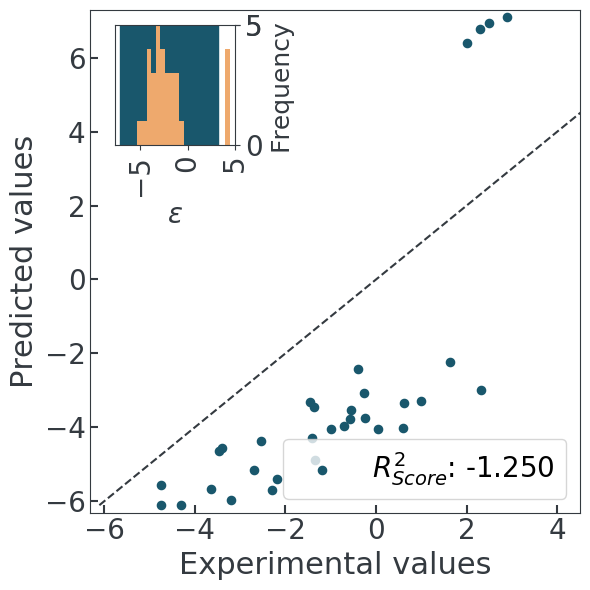

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import MultipleLocator

# Set global font to Arial
plt.rcParams['font.family'] = 'Arial'

font_color = '#343a40'

fig, ax1 = plt.subplots(figsize=(6, 6))

# Main scatter plot (train data only)
ax1.scatter(y1_train, y2_train, s=35, color=['#19576C'])

# Compute score using only the train data
score = get_score(train_actual=y1_train, train_predicted=y2_train)

# Show only the train score in the legend
ax1.legend(
    [f'$R^2_{{Score}}$: {score["Train_R2"]:.3f}'],
    loc='lower right',
    fontsize=20,
    frameon=True
)

# Axis labels
ax1.set_xlabel('Experimental values', fontsize=22, color=font_color)
ax1.set_ylabel('Predicted values', fontsize=22, color=font_color)

# Tick parameters and spine color match
ax1.tick_params(axis="both", direction="in", length=6, width=1.5, labelsize=20, colors=font_color)
for spine in ax1.spines.values():
    spine.set_color(font_color)

# Diagonal line based on train data
min_val = min(min(y1_train), min(y2_train))
max_val = max(max(y1_train), max(y2_train))
ax1.plot([min_val, max_val], [min_val, max_val], color=font_color, linestyle='--')

# Inset histogram (train residuals only)
left, bottom, width, height = [0.2, 0.75, 0.2, 0.2]
ax2 = fig.add_axes([left, bottom, width, height])

# Histogram shaded region
std = np.std(y2_train - y1_train)
mean = np.mean(y2_train - y1_train)
xx = mean - 2 * std
yy = 0
rec = patches.Rectangle((xx, yy), 4 * std, 600, color='#19576C')
ax2.add_patch(rec)

# Histogram itself
y, x, __ = ax2.hist(y2_train - y1_train, bins=20, color='#EEA96D')

# Tick styling for inset
ax2.xaxis.set_major_locator(plt.MaxNLocator(3))
ax2.yaxis.tick_right()
ax1.set_ylim(min_val-0.2, max_val+0.2)
# ax1.set_yticks([-8, 4, 2])
ax1.set_xlim(min_val-0.2, 4.5)
ax1.xaxis.set_major_locator(MultipleLocator(2))
# ax1.set_xticks([-8, 4, 2])
ax2.yaxis.set_tick_params(labelsize=20, colors=font_color)
ax2.xaxis.set_tick_params(labelsize=20, colors=font_color)
ax2.yaxis.set_label_position("right")

# Inset labels
ax2.set_ylabel('Frequency', fontsize=18, color=font_color)
ax2.set_xlabel(r'$\epsilon$', fontsize=20, color=font_color)
ax2.set_ylim(0, 5)
ax2.set_yticks([0, 5, 5])
# ax2.set_yticks([0, 5, 5])
ax2.tick_params(axis='x', labelrotation=90)

# Match spine color in inset
for spine in ax2.spines.values():
    spine.set_color(font_color)

plt.tight_layout()
plt.show()


In [40]:
ff = pd.DataFrame(X_train.astype(bool).sum(axis=0).sort_values(ascending=False))
ff = ff.rename(index={"Temp (Celsius)": "Temp"})

fft = pd.DataFrame(X_test.astype(bool).sum(axis=0).sort_values(ascending=False))
fft = fft.rename(index={"Temp (Celsius)": "Temp"})
ff3= ff.values.tolist()
ff3t= fft.values.tolist()
ff2 = [ item for elem in ff3 for item in elem]
ff2t = [ item for elem in ff3t for item in elem]

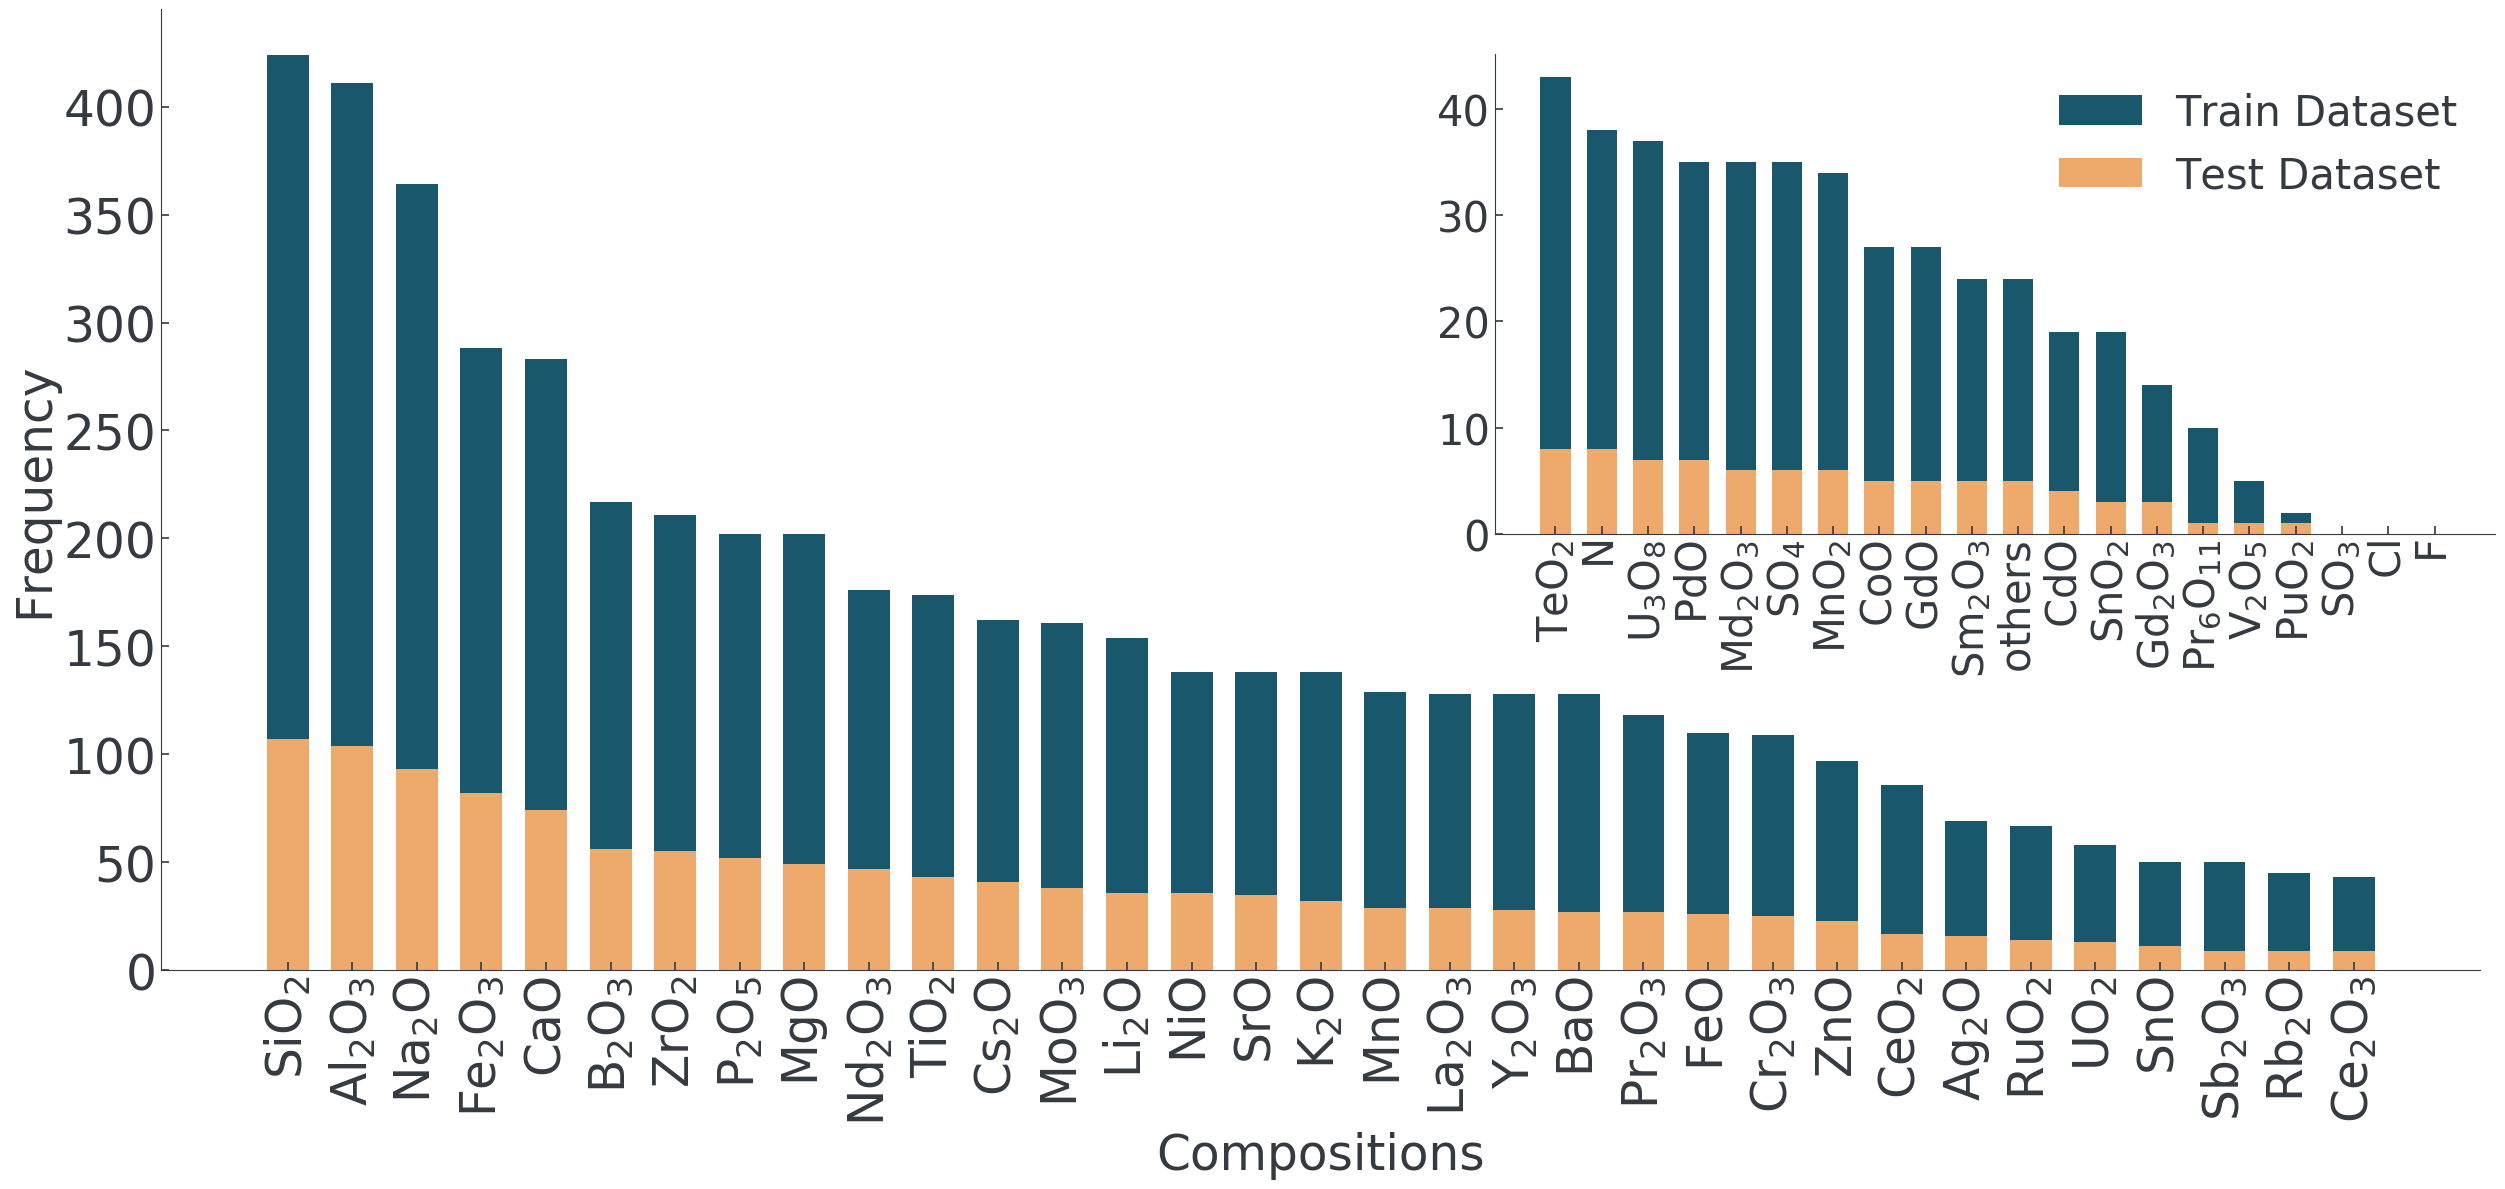

In [56]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import numpy as np
import re

# Font setup
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.weight'] = 'normal'
ff1 = ["temp" if x == "Temp (Celsius)" else x for x in ff1]
ff1t = ["temp" if x == "Temp (Celsius)" else x for x in ff1t]



# LaTeX subscript conversion
def convert_to_latex(chemical_formula):
    return re.sub(r'(\d+)', r'_{\1}', chemical_formula)

ff1_latex = [r'\mathrm{' + convert_to_latex(formula) + r'}' for formula in ff1]
ff1t_latex = [r'\mathrm{' + convert_to_latex(formula) + r'}' for formula in ff1t]

fig, ax1 = plt.subplots(figsize=(25, 12))
left, bottom, width, height = [0.60, 0.55, 0.4, 0.4]
ax2 = fig.add_axes([left, bottom, width, height])
bar_width = 0.65

# Bar colors
train_color = "#19576C"
test_color = "#EEA96D"

# Main bar plot
# ax1.bar(ff1[2:35], ff2[2:35], width=bar_width, color=train_color)
# ax1.bar(ff1[2:35], ff2t[2:35], width=bar_width, color=test_color)
indices = [i for i in range(len(ff1)) if i not in (1, 2) and i <= 34]
ax1.bar([ff1[i] for i in indices], [ff2[i] for i in indices], width=bar_width, color=train_color)
ax1.bar([ff1[i] for i in indices], [ff2t[i] for i in indices], width=bar_width, color=test_color)


# # Annotate
# for i in range(35):
#     ax1.annotate(str(ff2[i]), xy=(ff1[i], ff2[i]), ha='center', va='bottom', fontsize=30, color='#343a40')
#     ax1.annotate(str(ff2t[i]), xy=(ff1[i], ff2t[i]), ha='center', va='bottom', fontsize=30, color='#343a40')

# Aesthetics
ax1.set_xlabel('Compositions', fontsize=35, color='#343a40', fontname='Arial')
ax1.set_ylabel('Frequency', fontsize=35, color='#343a40', fontname='Arial')
ax1.set_xticks(range(33))
# ax1.set_xticklabels([f'${label}$' for label in ff1_latex[2:35]], rotation=90)
indices = [i for i in range(len(ff1_latex)) if i not in (1, 2) and i < 35]
ax1.set_xticklabels([f'${ff1_latex[i]}$' for i in indices], rotation=90)
ax1.tick_params(axis='both', direction='in', length=6, width=1.2, labelsize=35, colors='#343a40')
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    ax1.spines[spine].set_color('#343a40')

# Inset plot
ax2.bar(ff1[35:], ff2[35:], width=bar_width, color=train_color)
ax2.bar(ff1[35:], ff2t[35:], width=bar_width, color=test_color)

# for i in range(35, 57):
#     ax2.annotate(str(ff2[i]), xy=(ff1[i], ff2[i]), ha='center', va='bottom', fontsize=30, color='#343a40')
#     ax2.annotate(str(ff2t[i]), xy=(ff1[i], ff2t[i]), ha='center', va='bottom', fontsize=30, color='#343a40')

# ax2.set_xlabel('Compositions', fontsize=20, color='#343a40', fontname='Arial')
# ax2.set_ylabel('Frequency', fontsize=20, color='#343a40', fontname='Arial')
ax2.set_xticks(range(20))
ax2.set_xticklabels([f'${label}$' for label in ff1_latex[35:]], rotation=90)
ax2.tick_params(axis='both', direction='in', length=6, width=1.2, labelsize=30, colors='#343a40')
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    ax2.spines[spine].set_color('#343a40')
legend = ax2.legend(["Train Dataset", "Test Dataset"], fontsize=30, frameon=False)
for text in legend.get_texts():
    text.set_color('#343a40')


plt.tight_layout()
plt.show()


In [177]:
len(ff1[35:-3])

19

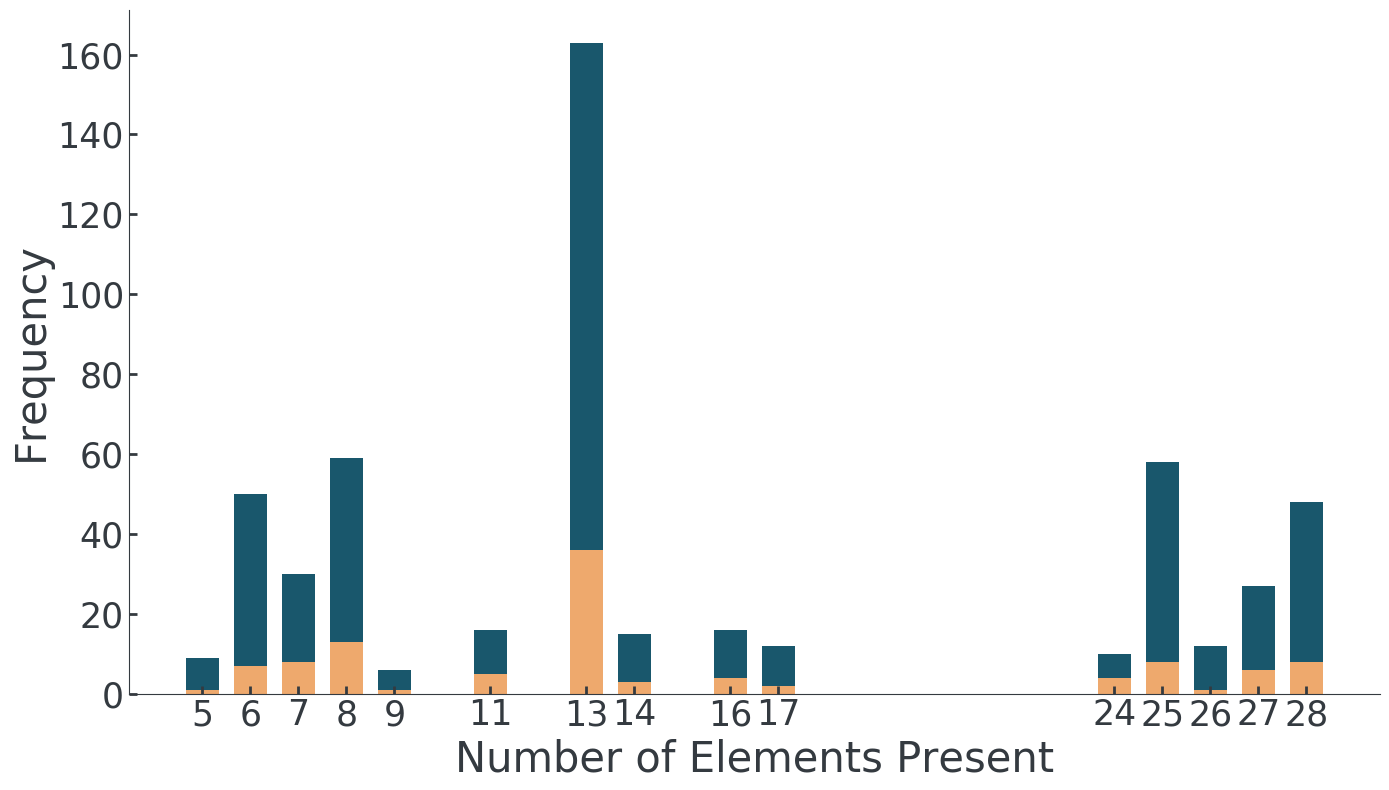

In [60]:
import matplotlib.pyplot as plt

# Ensure the x-values are aligned (union of all unique element counts)
xticks = sorted(set(zz1_train).union(set(zz1_test)))

# Create aligned bar heights, fill with 0 if missing
train_values = [zz_train.loc[x][0] if x in zz_train.index else 0 for x in xticks]
test_values = [zz_test.loc[x][0] if x in zz_test.index else 0 for x in xticks]

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
bar_width = 0.7



bar1 = ax.bar(
    xticks,
    train_values,
    bottom=test_values,  # now train is stacked above test
    color="#19576C",
    width=bar_width,
    label="Train Dataset"
)

# Reverse the stacking: test on bottom, train on top
bar2 = ax.bar(
    xticks,
    test_values,
    color="#EEA96D",
    width=bar_width,
    label="Test Dataset"
)

# Aesthetics
ax.set_ylabel("Frequency", fontsize=30, color='#343a40')
ax.set_xlabel("Number of Elements Present", fontsize=30, color='#343a40')
ax.set_xticks(xticks)
ax.set_xticklabels([str(x) for x in xticks], fontsize=20)
ax.tick_params(axis='both', direction='in', length=6, width=2, labelsize=25, colors='#343a40')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#343a40')
ax.spines['bottom'].set_color('#343a40')

# for i, x in enumerate(xticks):
#     total_height = train_values[i] + test_values[i]
#     if total_height > 0:
#         ax.annotate(
#             str(total_height),
#             xy=(x, total_height + 5),  # Adjust the offset (5) for spacing above bar
#             ha='center',
#             va='bottom',
#             fontsize=16,
#             color='#343a40'
#         )


# for i, x in enumerate(xticks):
#     if test_values[i] > 0:
#         ax.annotate(str(test_values[i]), xy=(x, test_values[i] / 2), ha='center', va='center', fontsize=14, color='black')
#     if train_values[i] > 0:
#         ax.annotate(str(train_values[i]), xy=(x, test_values[i] + train_values[i] / 2), ha='center', va='center', fontsize=14, color='white')


# Legend
# ax.legend(loc='upper right', fontsize=18, frameon=False)

# Final touches
plt.minorticks_off()
fig.tight_layout()
plt.show()


## Shap Analysis

In [12]:
#comp_NLP
X_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_train_split_X.csv')
y_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_train_split_y.csv')
X_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_test_split_X.csv')
y_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_test_split_y.csv')

import json
file2 = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_NN_dissolution_composition/NN_dissolution_composition_0/00_Pipeline_NN_dissolution_composition_Node_Data Normalization_means_and_stds.json"
ms_file = json.load(open(file2, "rb"))
import pickle
file_name = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_NN_dissolution_composition/NN_dissolution_composition_0/01_Pipeline_NN_dissolution_composition_Node_Optuna NN_Trial_101_8_model.pkl"
nn_model_loaded = pickle.load(open(file_name, "rb"))

In [23]:
#des_NLP
X_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited/maxpooled_processed_output_edited/01_Pipeline_umap_dissolution_maxpooled_Node_train_test_split_train_split_X.csv')
y_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited/maxpooled_processed_output_edited/01_Pipeline_umap_dissolution_maxpooled_Node_train_test_split_train_split_y.csv')
X_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited/maxpooled_processed_output_edited/01_Pipeline_umap_dissolution_maxpooled_Node_train_test_split_test_split_X.csv')
y_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited/maxpooled_processed_output_edited/01_Pipeline_umap_dissolution_maxpooled_Node_train_test_split_test_split_y.csv')

import json
file2 = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_NN_dissolution_descriptor/NN_dissolution_descriptor_0/00_Pipeline_NN_dissolution_descriptor_Node_Data Normalization_means_and_stds.json"
ms_file = json.load(open(file2, "rb"))
import pickle
file_name = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_NN_dissolution_descriptor/NN_dissolution_descriptor_0/01_Pipeline_NN_dissolution_descriptor_Node_Optuna NN_Trial_63_9_model.pkl"
nn_model_loaded = pickle.load(open(file_name, "rb"))


In [38]:
# XGB comp Model
X_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_train_split_X.csv')
y_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_train_split_y.csv')
X_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_test_split_X.csv')
y_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited_composition/maxpooled_processed_output_edited_composition/01_Pipeline_umap_dissolution_maxpooled_comp_Node_train_test_split_test_split_y.csv')

import json
file2 = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_dissolution_XGB_composition/xgb_dissolution_composition_0/00_Pipeline_xgb_dissolution_composition_Node_Data Normalization_means_and_stds.json"
ms_file = json.load(open(file2, "rb"))
import pickle
file_name = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_dissolution_XGB_composition/xgb_dissolution_composition_0/01_Pipeline_xgb_dissolution_composition_Node_Optuna XGBoost_Trial_44_3_model.pkl"
xgb_model_loaded = pickle.load(open(file_name, "rb"))

In [31]:
# XGB des Model
X_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited/maxpooled_processed_output_edited/01_Pipeline_umap_dissolution_maxpooled_Node_train_test_split_train_split_X.csv')
y_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited/maxpooled_processed_output_edited/01_Pipeline_umap_dissolution_maxpooled_Node_train_test_split_train_split_y.csv')
X_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited/maxpooled_processed_output_edited/01_Pipeline_umap_dissolution_maxpooled_Node_train_test_split_test_split_X.csv')
y_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/maxpooled_processed_output_edited/maxpooled_processed_output_edited/01_Pipeline_umap_dissolution_maxpooled_Node_train_test_split_test_split_y.csv')
import json
file2 = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_dissolution_XGB_descriptor/xgb_dissolution_descriptor_0/00_Pipeline_xgb_dissolution_descriptor_Node_Data Normalization_means_and_stds.json"
ms_file = json.load(open(file2, "rb"))
import pickle
file_name = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_dissolution_XGB_descriptor/xgb_dissolution_descriptor_0/01_Pipeline_xgb_dissolution_descriptor_Node_Optuna XGBoost_Trial_43_4_model.pkl"
xgb_model_loaded = pickle.load(open(file_name, "rb"))


In [40]:
## PCA NN Model
#comp_NLP
X_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/pca_maxpooled_processed_output_edited_composition/pca_maxpooled_processed_output_edited_composition/01_Pipeline_pca_dissolution_maxpooled_comp_Node_train_test_split_train_split_X.csv')
y_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/pca_maxpooled_processed_output_edited_composition/pca_maxpooled_processed_output_edited_composition/01_Pipeline_pca_dissolution_maxpooled_comp_Node_train_test_split_train_split_y.csv')
X_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/pca_maxpooled_processed_output_edited_composition/pca_maxpooled_processed_output_edited_composition/01_Pipeline_pca_dissolution_maxpooled_comp_Node_train_test_split_test_split_X.csv')
y_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/pca_maxpooled_processed_output_edited_composition/pca_maxpooled_processed_output_edited_composition/01_Pipeline_pca_dissolution_maxpooled_comp_Node_train_test_split_test_split_y.csv')

import json
file2 = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_NN_dissolution_composition_pca/NN_dissolution_composition_1/00_Pipeline_NN_dissolution_composition_Node_Data Normalization_means_and_stds.json"
ms_file = json.load(open(file2, "rb"))
import pickle
file_name = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_NN_dissolution_composition_pca/NN_dissolution_composition_1/01_Pipeline_NN_dissolution_composition_Node_Optuna NN_Trial_130_1_model.pkl"
nn_model_loaded = pickle.load(open(file_name, "rb"))

In [ ]:
## PCA NN des model
#des_NLP
X_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/pca_maxpooled_processed_output_edited/01_Pipeline_pca_dissolution_maxpooled_Node_train_test_split_train_split_X.csv')
y_train = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/pca_maxpooled_processed_output_edited/01_Pipeline_pca_dissolution_maxpooled_Node_train_test_split_train_split_y.csv')
X_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/pca_maxpooled_processed_output_edited/01_Pipeline_pca_dissolution_maxpooled_Node_train_test_split_test_split_X.csv')
y_test = pd.read_csv('/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/glass_setup/pca_maxpooled_processed_output_edited/01_Pipeline_pca_dissolution_maxpooled_Node_train_test_split_test_split_y.csv')

import json
file2 = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_NN_dissolution_descriptor_pca/NN_dissolution_descriptor_0/00_Pipeline_NN_dissolution_descriptor_Node_Data Normalization_means_and_stds.json"
ms_file = json.load(open(file2, "rb"))
import pickle
file_name = "/home/civil/staff/sidm3rg.cstaff/Documents/PU_Learning/MLPipeline_results_NN_dissolution_descriptor_pca/NN_dissolution_descriptor_0/01_Pipeline_NN_dissolution_descriptor_Node_Optuna NN_Trial_125_4_model.pkl"
nn_model_loaded = pickle.load(open(file_name, "rb"))

In [24]:
X_train

,O_per,NF_per,NM_per,valency_NF,valency_NM,automic_mass,automic_vol,A_number,automic_radius,vdwall_radius,...,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10
0,0.604258,0.263289,0.132453,303.856582,54.496952,6367.196059,2592.569508,3109.021782,655.302606,584.618557,...,9.886235,7.091496,11.033625,4.003721,4.119290,10.462847,7.934297,13.472701,7.244522,10.469156
1,0.778575,0.221425,0.000000,231.947999,0.000000,10694.794510,2935.879724,4915.062616,661.541056,578.206435,...,25.232798,13.547860,20.322374,10.504789,7.235515,-0.642869,0.724299,6.703285,14.743387,13.029710
2,0.680481,0.251867,0.067652,288.237442,24.722650,6607.828004,2492.356807,3270.192188,608.381054,541.555465,...,2.536642,-10.525118,13.190824,22.656776,17.525904,8.987157,6.080177,-3.493712,4.978676,12.194653
3,0.689389,0.214713,0.095898,223.317840,43.223119,6560.149082,2437.806720,3232.728171,576.806561,506.716521,...,14.707810,16.425592,16.566751,9.725747,10.351345,10.018402,-0.338060,7.217171,9.325678,1.958347
4,0.604377,0.273450,0.122172,323.059845,45.288333,6604.198935,2523.507004,3213.877903,638.158038,575.474416,...,21.245863,6.333387,11.956010,24.010519,15.122143,15.624169,7.067569,4.252579,21.373037,2.583429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
419,0.677498,0.266706,0.055796,310.134637,21.184254,6516.239178,2463.366574,3231.271936,605.634018,539.512238,...,14.707810,16.425592,16.566751,9.725747,10.351345,10.018402,-0.338060,7.217171,9.325678,1.958347
420,0.607871,0.244406,0.147723,279.521217,56.497294,6255.325773,2497.868188,3060.020852,620.186986,551.894312,...,9.886235,7.091496,11.033625,4.003721,4.119290,10.462847,7.934297,13.472701,7.244522,10.469156
421,0.617490,0.287396,0.095114,339.660000,36.760000,6431.590048,2572.231523,3174.240000,644.766500,582.372900,...,11.177767,-5.496496,23.767889,13.830687,-18.680714,8.916791,26.604070,-1.671965,-4.014891,-0.230322
422,0.681130,0.212140,0.106730,240.985497,47.606134,6910.567050,2629.354044,3409.151016,629.082843,555.129954,...,10.893426,6.653773,12.459437,12.606045,16.046923,16.697403,17.818232,6.114308,5.683449,6.101972


In [25]:
P = MLP.Pipe(name="Combined", output="2a_xgb_results_Si_BERT_ullo_ZERO")
P.add(MLP.data_cleaning.normalize_data(mean=ms_file["means"], std=ms_file["stds"]))  ##(x-mean)/(std)

X_train_N, y_train_N = P((X_train, y_train))
X_test_N, y_test_N = P((X_test, y_test))


Pipeline Combined is running

Node 0 running.
Node name:  Data Normalization

Pipeline Combined is running

Node 0 running.
Node name:  Data Normalization


In [26]:
y_train_N

,rate (gm/m2/day)
0,0.193109
1,0.476594
2,-0.210725
3,-1.407863
4,-0.554867
...,...
419,-1.530019
420,-0.263964
421,0.346820
422,1.249878


In [27]:
import torch

In [28]:
feature_names = X_train_N.columns


In [29]:
back = torch.tensor(X_train_N.values).float()


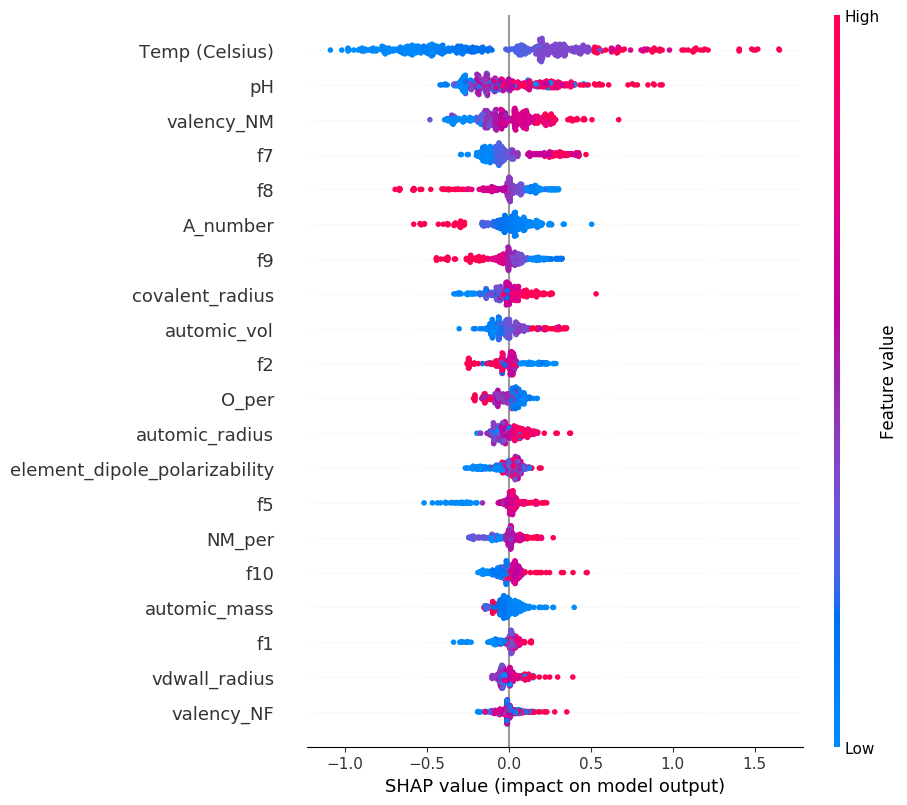

In [11]:
import shap

# For neural networks, use DeepExplainer
# model: your trained neural network
# back: a representative background sample (e.g., 100 samples from training set)

explainer = shap.DeepExplainer(nn_model_loaded, back)
shap_values = explainer.shap_values(back)

# Visualization example
shap.summary_plot(shap_values, back, feature_names=X_train_N.columns)


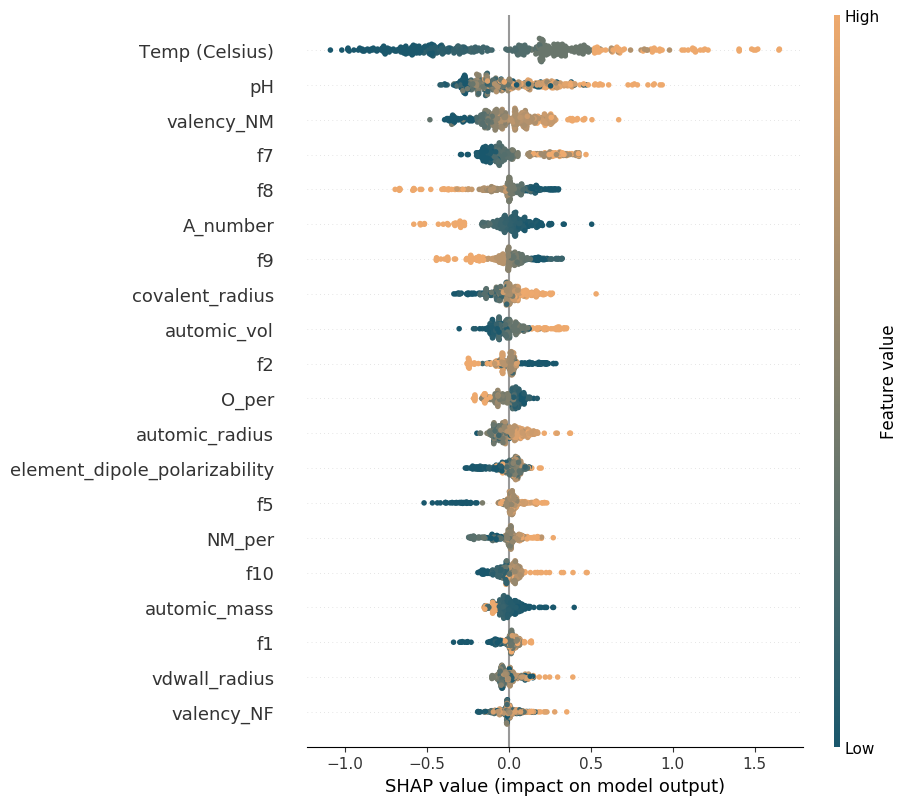

In [12]:
import shap

# For neural networks, use DeepExplainer
# model: your trained neural network
# back: a representative background sample (e.g., 100 samples from training set)
from matplotlib.colors import LinearSegmentedColormap
explainer = shap.DeepExplainer(nn_model_loaded, back)
shap_values = explainer.shap_values(back)

custom_cmap = LinearSegmentedColormap.from_list(
    "custom", ["#19576C", "#EEA96D"]  # green → yellow → red
)

# Visualization example
shap.summary_plot(shap_values, back, cmap=custom_cmap, feature_names=X_train_N.columns)


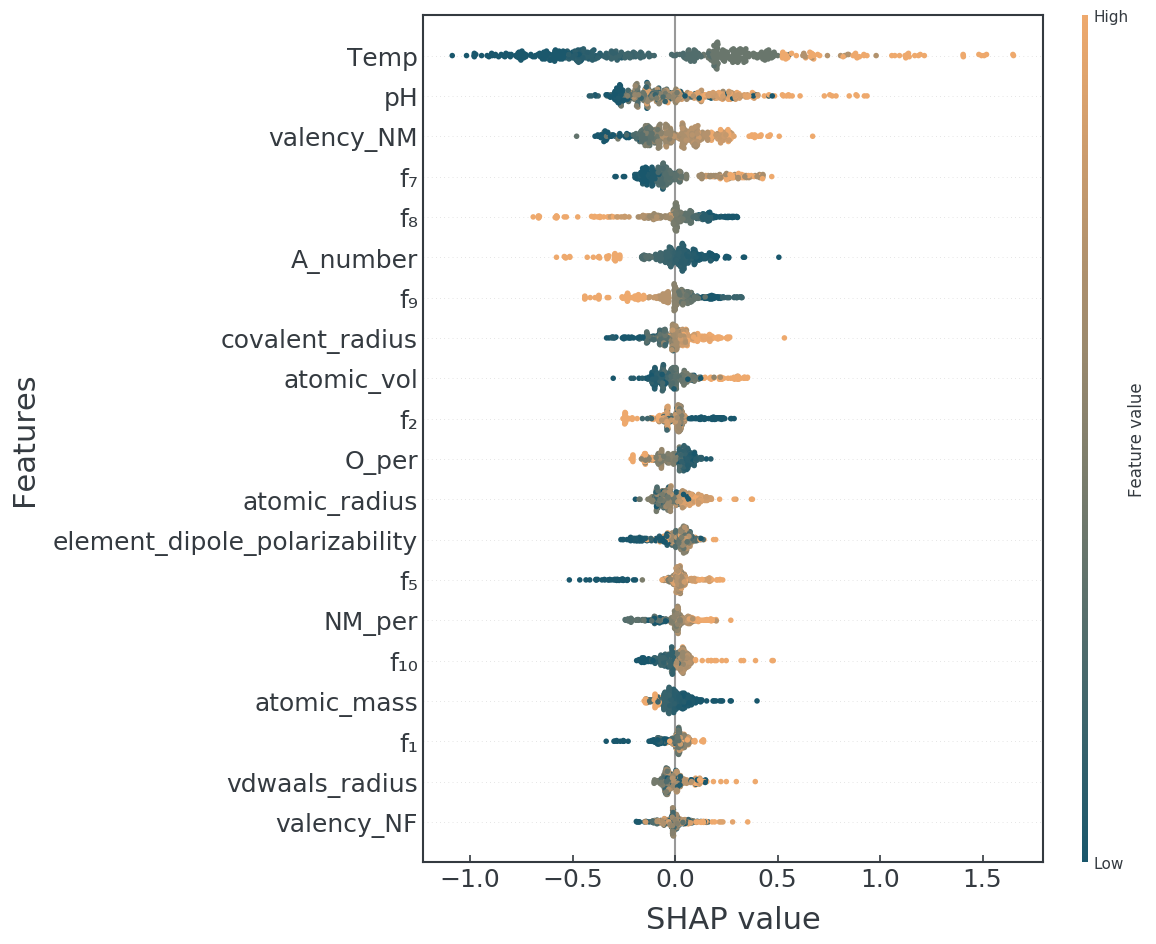

In [30]:
import shap
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import re

# --- Custom color map ---
custom_cmap = LinearSegmentedColormap.from_list(
    "custom", ["#19576C", "#EEA96D"]
)

# --- Global style ---
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#343a40'
plt.rcParams['axes.labelcolor'] = '#343a40'
plt.rcParams['xtick.color'] = '#343a40'
plt.rcParams['ytick.color'] = '#343a40'
plt.rcParams['axes.linewidth'] = 1.5

# --- Compute SHAP values ---
explainer = shap.DeepExplainer(nn_model_loaded, back)
shap_values = explainer.shap_values(back)

# --- Rename features ---
feature_names = X_train_N.columns.tolist()
rename_map = {
    "Temp (Celsius)": "Temp",
    "automic_vol":"atomic_vol",
    "automic_radius":"atomic_radius",
    "automic_mass":"atomic_mass",
    "vdwall_radius":"vdwaals_radius",
}
feature_names = [rename_map.get(name, name) for name in feature_names]

# --- Function to make subscripts Matplotlib-safe ---
def format_subscripts(name):
    # Replace digits following letters with subscript unicode characters (₀–₉)
    sub_map = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")
    # e.g., 'SiO2' -> 'SiO₂'
    formatted = re.sub(r'([A-Za-z])(\d+)', 
                       lambda m: m.group(1) + m.group(2).translate(sub_map),
                       name)
    return formatted

formatted_features = [format_subscripts(name) for name in feature_names]

# --- Create SHAP summary plot ---
shap.summary_plot(
    shap_values,
    back,
    cmap=custom_cmap,
    feature_names=formatted_features,
    show=False
)

# --- Access figure and axes ---
fig = plt.gcf()
ax = fig.axes[0]
font_color = '#343a40'

# Force wider layout
fig.set_size_inches(10, 11)

# --- Aesthetics ---
ax.set_title("")
ax.set_xlabel("SHAP value", fontsize=22, color=font_color, labelpad=10)
ax.set_ylabel("Features", fontsize=22, color=font_color, labelpad=10)
ax.tick_params(axis="both", direction="in", length=5, width=1.2, labelsize=18, colors=font_color)

# --- Spines ---
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color(font_color)
    spine.set_linewidth(1.5)

plt.show()


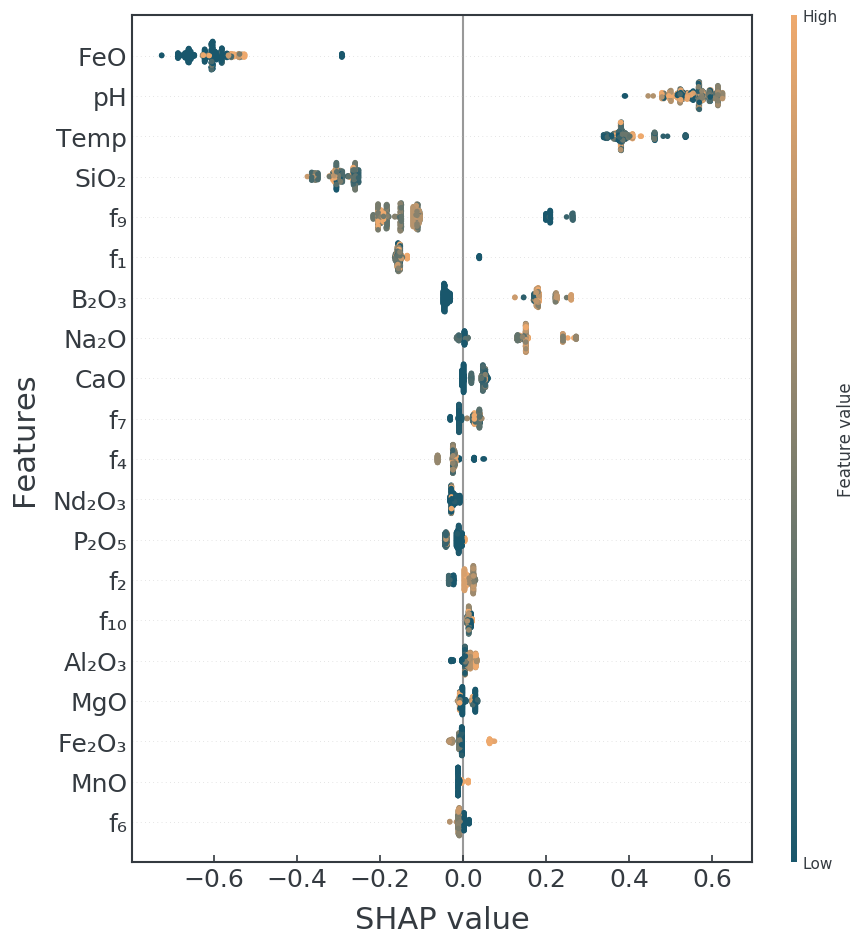

In [39]:
import shap
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import re

# --- Custom color map ---
custom_cmap = LinearSegmentedColormap.from_list(
    "custom", ["#19576C", "#EEA96D"]
)

# --- Global style ---
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#343a40'
plt.rcParams['axes.labelcolor'] = '#343a40'
plt.rcParams['xtick.color'] = '#343a40'
plt.rcParams['ytick.color'] = '#343a40'
plt.rcParams['axes.linewidth'] = 1.5

# --- Compute SHAP values for XGBoost ---
# Replace `xgb_model` with your trained model
# and `X_train` with your training data (as a pandas DataFrame)
explainer = shap.TreeExplainer(xgb_model_loaded)
shap_values = explainer.shap_values(X_train)

# --- Rename features ---
feature_names = X_train.columns.tolist()
rename_map = {
    "Temp (Celsius)": "Temp",
    # Add other renaming rules if needed
}

feature_names = [rename_map.get(name, name) for name in feature_names]

# --- Function to make subscripts Matplotlib-safe ---
def format_subscripts(name):
    # Replace digits following letters with subscript unicode characters (₀–₉)
    sub_map = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")
    # e.g., 'SiO2' -> 'SiO₂'
    formatted = re.sub(r'([A-Za-z])(\d+)', 
                       lambda m: m.group(1) + m.group(2).translate(sub_map),
                       name)
    return formatted

formatted_features = [format_subscripts(name) for name in feature_names]

# --- Create SHAP summary plot ---
shap.summary_plot(
    shap_values,
    X_train,
    cmap=custom_cmap,
    feature_names=formatted_features,
    show=False
)

# --- Access figure and axes ---
fig = plt.gcf()
ax = fig.axes[0]
font_color = '#343a40'

# Force wider layout
fig.set_size_inches(10, 11)

# --- Aesthetics ---
ax.set_title("")
ax.set_xlabel("SHAP value", fontsize=22, color=font_color, labelpad=10)
ax.set_ylabel("Features", fontsize=22, color=font_color, labelpad=10)
ax.tick_params(axis="both", direction="in", length=5, width=1.2, labelsize=18, colors=font_color)

# --- Spines ---
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color(font_color)
    spine.set_linewidth(1.5)

plt.show()


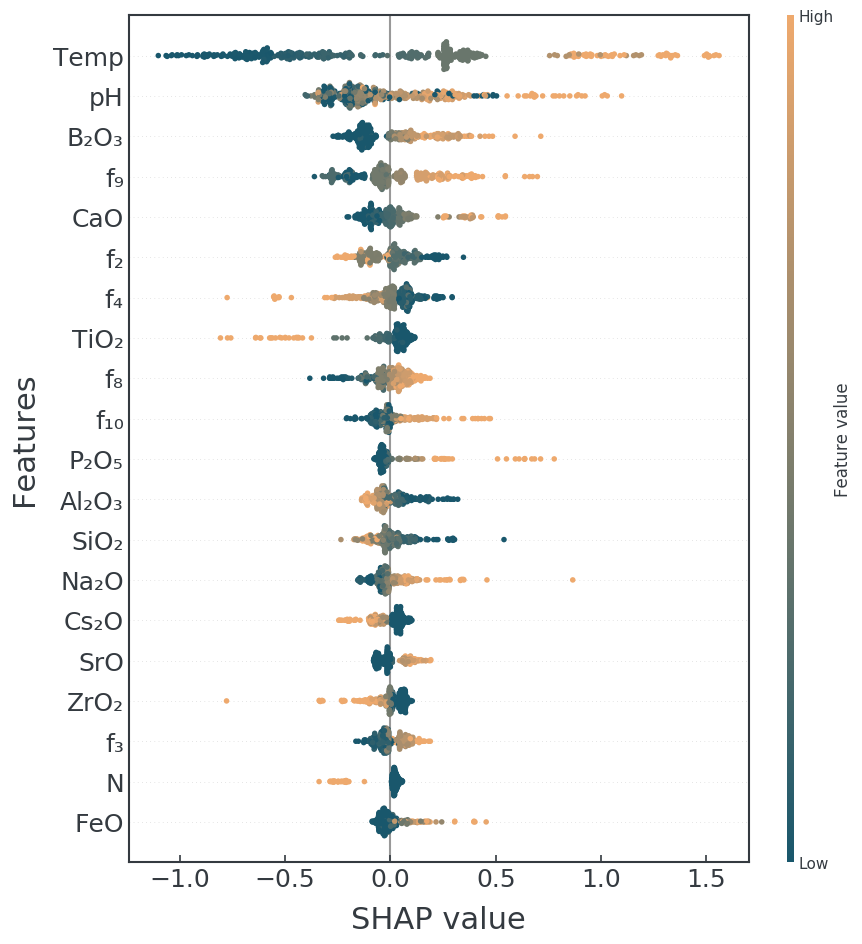

In [52]:
import shap
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import re

# --- Custom color map ---
custom_cmap = LinearSegmentedColormap.from_list(
    "custom", ["#19576C", "#EEA96D"]
)

# --- Global style ---
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#343a40'
plt.rcParams['axes.labelcolor'] = '#343a40'
plt.rcParams['xtick.color'] = '#343a40'
plt.rcParams['ytick.color'] = '#343a40'
plt.rcParams['axes.linewidth'] = 1.5

# --- Compute SHAP values ---
explainer = shap.DeepExplainer(nn_model_loaded, back)
shap_values = explainer.shap_values(back)

# --- Rename features ---
feature_names = X_train_N.columns.tolist()
rename_map = {
    "Temp (Celsius)": "Temp",
}
feature_names = [rename_map.get(name, name) for name in feature_names]

# --- Function to make subscripts Matplotlib-safe ---
def format_subscripts(name):
    # Replace digits following letters with subscript unicode characters (₀–₉)
    sub_map = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")
    # e.g., 'SiO2' -> 'SiO₂'
    formatted = re.sub(r'([A-Za-z])(\d+)', 
                       lambda m: m.group(1) + m.group(2).translate(sub_map),
                       name)
    return formatted

formatted_features = [format_subscripts(name) for name in feature_names]

# --- Create SHAP summary plot ---
shap.summary_plot(
    shap_values,
    back,
    cmap=custom_cmap,
    feature_names=formatted_features,
    show=False
)

# --- Access figure and axes ---
fig = plt.gcf()
ax = fig.axes[0]
font_color = '#343a40'

# Force wider layout
fig.set_size_inches(10, 11)

# --- Aesthetics ---
ax.set_title("")
ax.set_xlabel("SHAP value", fontsize=22, color=font_color, labelpad=10)
ax.set_ylabel("Features", fontsize=22, color=font_color, labelpad=10)
ax.tick_params(axis="both", direction="in", length=5, width=1.2, labelsize=18, colors=font_color)

# --- Spines ---
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color(font_color)
    spine.set_linewidth(1.5)

plt.show()


findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.


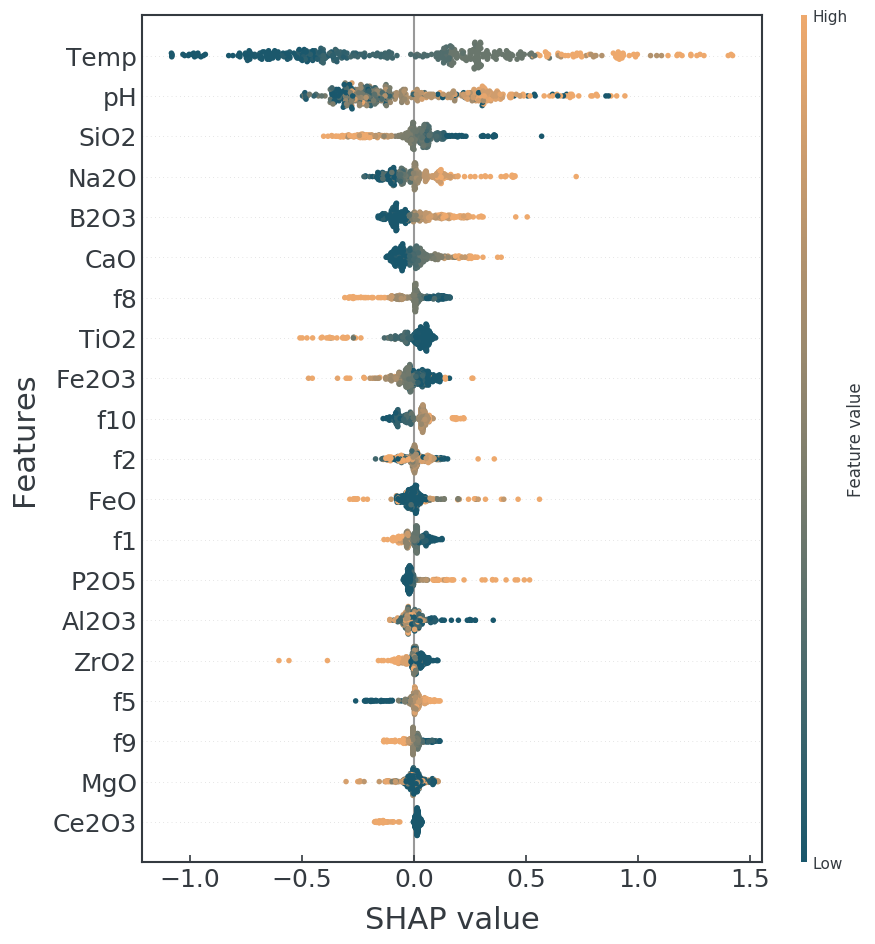

In [33]:
import shap
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# --- Custom color map ---
custom_cmap = LinearSegmentedColormap.from_list(
    "custom", ["#19576C", "#EEA96D"]
)

# --- Global style ---
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#343a40'
plt.rcParams['axes.labelcolor'] = '#343a40'
plt.rcParams['xtick.color'] = '#343a40'
plt.rcParams['ytick.color'] = '#343a40'
plt.rcParams['axes.linewidth'] = 1.5

# --- Compute SHAP values ---
explainer = shap.DeepExplainer(nn_model_loaded, back)
shap_values = explainer.shap_values(back)

# --- Rename features ---
feature_names = X_train_N.columns.tolist()
rename_map = {
    "Temp (Celsius)": "Temp",
    "automic_vol":"atomic_vol",
    "automic_radius":"atomic_radius",
    "automic_mass":"atomic_mass",
    "vdwall_radius":"vdwaals_radius",
}
feature_names = [rename_map.get(name, name) for name in feature_names]

# --- Create SHAP summary plot ---
shap.summary_plot(
    shap_values,
    back,
    cmap=custom_cmap,
    feature_names=feature_names,
    show=False
)

# --- Access figure and axes ---
fig = plt.gcf()
ax = fig.axes[0]
font_color = '#343a40'

# Force wider layout
fig.set_size_inches(10, 11)

# --- Aesthetics ---
ax.set_title("")
ax.set_xlabel("SHAP value", fontsize=22, color=font_color, labelpad=10)
ax.set_ylabel("Features", fontsize=22, color=font_color, labelpad=10)
ax.tick_params(axis="both", direction="in", length=5, width=1.2, labelsize=18, colors=font_color)

# --- Spines ---
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color(font_color)
    spine.set_linewidth(1.5)

# --- Widen x-axis ---
# x_min, x_max = ax.get_xlim()
# span = x_max - x_min
# ax.set_xlim(x_min - 0.1 * span, x_max + 0.1 * span)
# ax.set_xticks(np.arange(-1.0, 2.0, 0.5))

# # --- Colorbar tweaks ---


# # --- Adjust layout for more breathing room ---
# plt.subplots_adjust(left=0, right=0.4, bottom=0.12, top=0.95)

plt.show()


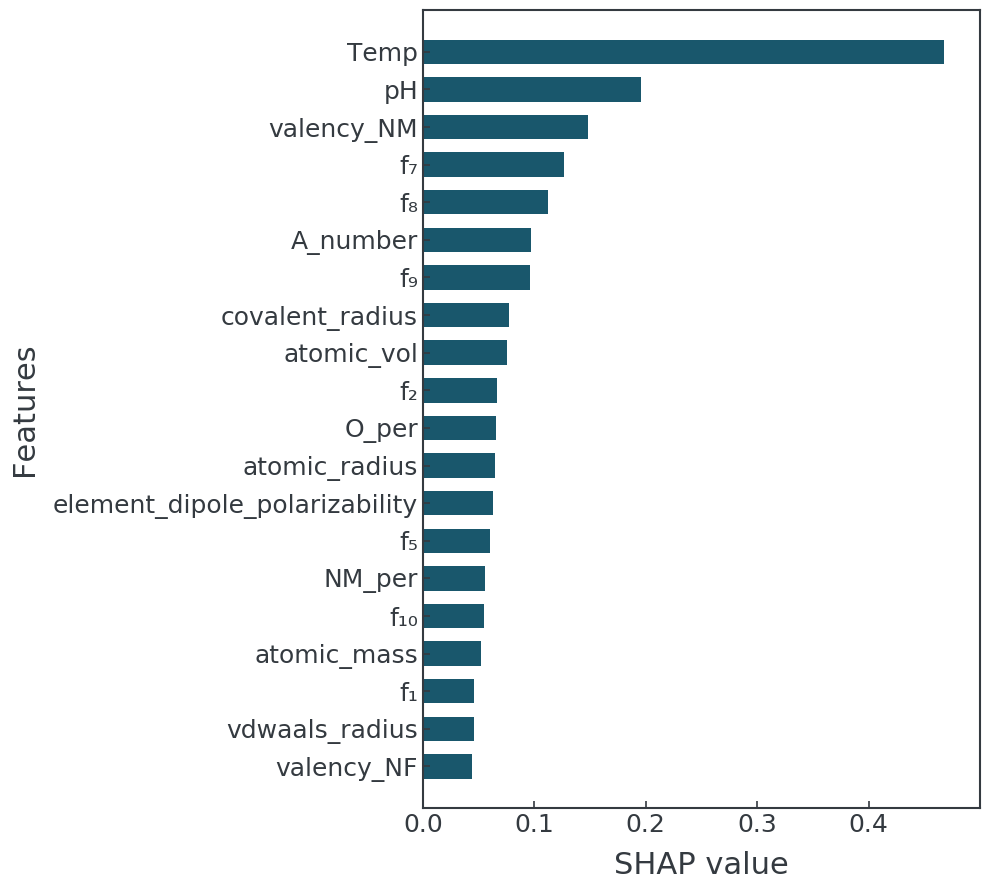

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import re

# --- Global plot styling ---
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#343a40'
plt.rcParams['axes.labelcolor'] = '#343a40'
plt.rcParams['xtick.color'] = '#343a40'
plt.rcParams['ytick.color'] = '#343a40'
plt.rcParams['axes.linewidth'] = 1.5

font_color = '#343a40'

# --- Rename features if needed ---
feature_names = X_train_N.columns.tolist()
rename_map = {
    "Temp (Celsius)": "Temp",
    "automic_vol":"atomic_vol",
    "automic_radius":"atomic_radius",
    "automic_mass":"atomic_mass",
    "vdwall_radius":"vdwaals_radius",
}
feature_names = [rename_map.get(name, name) for name in feature_names]

# --- Format subscripts (e.g. SiO2 → SiO₂) ---
def format_subscripts(name):
    sub_map = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")
    return re.sub(
        r'([A-Za-z])(\d+)',
        lambda m: m.group(1) + m.group(2).translate(sub_map),
        name
    )

formatted_features = [format_subscripts(name) for name in feature_names]

# --- Compute mean absolute SHAP values ---
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# --- Sort top 20 features ---
sorted_idx = np.argsort(mean_abs_shap)[::-1][:20]
y_pos = np.arange(len(sorted_idx))

# --- Create figure ---
fig, ax = plt.subplots(figsize=(10, 9))

# --- Bar plot ---
bars = ax.barh(
    y_pos,
    mean_abs_shap[sorted_idx],
    color="#19576C",
    height=0.65
)

# --- Apply formatted names for y-axis ---
ax.set_yticks(y_pos)
ax.set_yticklabels(np.array(formatted_features)[sorted_idx], fontsize=14, color=font_color)
ax.set_xticks(np.arange(0.0, 0.51, 0.1))

ax.set_xticklabels([f"{x:.1f}" for x in np.arange(0.0, 0.5, 0.1)], fontsize=14, color=font_color)

ax.invert_yaxis()  # top feature at top

# --- Axis labels ---
ax.set_xlabel("SHAP value", fontsize=22, color=font_color, labelpad=10)
ax.set_ylabel("Features", fontsize=22, color=font_color, labelpad=10)

# --- Tick styling ---
ax.tick_params(axis="both", direction="in", length=5, width=1.2, labelsize=18, colors=font_color)

# --- Spines styling ---
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color(font_color)
    spine.set_linewidth(1.5)

# --- Spacing ---
ax.margins(y=0.04)
plt.tight_layout()
plt.show()
